# Roofline Analysis: A Practical Guide

**Goal**: Understand what roofline analysis actually tells you (and doesn't tell you) about performance. This tutorial compares three generations of TPU hardware (four configurations) to show how bottlenecks shift across hardware and across operations.

---

## Table of Contents

1. **What is a Roofline?** - The mental model
2. **Anatomy of a Roofline Plot** - Building one from scratch
3. **Hardware Comparison** - Where do kernels land across TPU generations?
4. **Arithmetic Intensity** - What moves you on the x-axis, and why fusion matters
5. **Measuring FLOPs in JAX** - Using `cost_analysis` on real hardware
6. **Common Misconceptions** - With worked examples
7. **What Rooflines Can't Tell You** - Limitations and caveats
8. **Summary** - What to do next

In [ ]:
# @title Setup and Hardware Config { display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Force matplotlib back to default style to fix hidden axes/titles
plt.style.use('default')

# --- Hardware Specifications (per chip) ---
HW_SPECS = {
    "v7x (fp8)":  {"peak_flops": 4614, "peak_bw": 7.2,  "color": "#d62728"},  # Red
    "v7x (bf16)": {"peak_flops": 2307, "peak_bw": 7.2,  "color": "#9D00FF"},  # Purple
    "v6e":         {"peak_flops": 918,  "peak_bw": 1.6,  "color": "#2ca02c"},  # Green
    "v5p":         {"peak_flops": 459,  "peak_bw": 2.76, "color": "#1f77b4"},  # Blue
}

# Pre-calculate ridge points
for name, spec in HW_SPECS.items():
    spec["ridge"] = spec["peak_flops"] / spec["peak_bw"]

print(f"{'-'*80}")
print(f"{'Hardware':<15} | {'Peak Compute':<15} | {'Peak BW':<12} | {'Ridge Point':<15}")
print(f"{'-'*80}")
for name, spec in HW_SPECS.items():
    print(f"{name:<15} | {spec['peak_flops']:<6} TFLOPS   | {spec['peak_bw']:<5} TB/s  | {spec['ridge']:<6.1f} FLOP/Byte")
print(f"{'-'*80}")

# Visual defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


# --- Arithmetic Intensity Helpers ---
def calculate_ai_matmul(M, N, K, dtype_bytes=2):
    """AI for C[M,N] = A[M,K] @ B[K,N]. Counts reads of A,B and write of C."""
    flops = 2 * M * N * K
    bytes_moved = (M * K + K * N + M * N) * dtype_bytes
    return {"flops": flops, "bytes": bytes_moved, "ai": flops / bytes_moved}

def calculate_ai_elementwise(num_elements, flops_per_element=1, dtype_bytes=2):
    """AI for elementwise ops (read input + write output)."""
    flops = num_elements * flops_per_element
    bytes_moved = 2 * num_elements * dtype_bytes
    return flops / bytes_moved

def calculate_ai_layernorm(hidden_dim, batch_seq, dtype_bytes=2):
    """Approximate AI for LayerNorm."""
    elements = hidden_dim * batch_seq
    flops = elements * 10  # mean, var, normalize, scale, shift
    bytes_moved = (3 * elements + 2 * hidden_dim) * dtype_bytes
    return flops / bytes_moved

def roofline_perf(ai, peak_flops, peak_bw):
    """Achievable performance at a given AI: min(AI * BW, peak_flops)."""
    return min(ai * peak_bw, peak_flops)


# JAX Setup (Optional)
HAS_JAX = False
HAS_ACCELERATOR = False
try:
    import jax
    import jax.numpy as jnp
    from jax import random
    HAS_JAX = True
except ImportError:
    print("Note: JAX not found. FLOP counting examples will use theoretical values.")

--------------------------------------------------------------------------------
Hardware        | Peak Compute    | Peak BW      | Ridge Point    
--------------------------------------------------------------------------------
v7x (fp8)       | 4614   TFLOPS   | 7.2   TB/s  | 640.8  FLOP/Byte
v7x (bf16)      | 2307   TFLOPS   | 7.2   TB/s  | 320.4  FLOP/Byte
v6e             | 918    TFLOPS   | 1.6   TB/s  | 573.8  FLOP/Byte
v5p             | 459    TFLOPS   | 2.76  TB/s  | 166.3  FLOP/Byte
--------------------------------------------------------------------------------
Note: JAX not found. FLOP counting examples will use theoretical values.


---

# 1. What is a Roofline?

## The Core Idea

> **A roofline model shows the maximum achievable performance for a kernel, based on its arithmetic intensity, bounded by either compute or memory bandwidth.**

Think of it like a speed limit sign. The roofline doesn't tell you how fast your car *is* going — it tells you the fastest you *could* go given the road conditions (memory bandwidth) and your engine (compute).

## The Two Ceilings

Every kernel's performance is limited by one of two things:

| Ceiling | What Limits You | When It Happens |
|---------|-----------------|-----------------|
| **Compute Bound** | Peak FLOPS of the hardware | Lots of math per byte loaded (high arithmetic intensity) |
| **Memory Bound** | Peak memory bandwidth | Lots of data movement per FLOP (low arithmetic intensity) |

## Arithmetic Intensity (AI)

This single number determines which ceiling you hit:

$$\text{Arithmetic Intensity} = \frac{\text{FLOPs (operations performed)}}{\text{Bytes moved to/from memory}}$$

- **Low AI** (e.g., elementwise ops): Memory bound — waiting for data
- **High AI** (e.g., large matmuls): Compute bound — waiting for ALUs

The **ridge point** is the AI where both ceilings are equal. It's a property of the *hardware*, not your kernel.

---

# 2. Anatomy of a Roofline Plot

Let's build a roofline for a single chip first. This shows the key components: the memory-bandwidth slope, the compute ceiling, the ridge point, and the feasible region where all kernels must live.

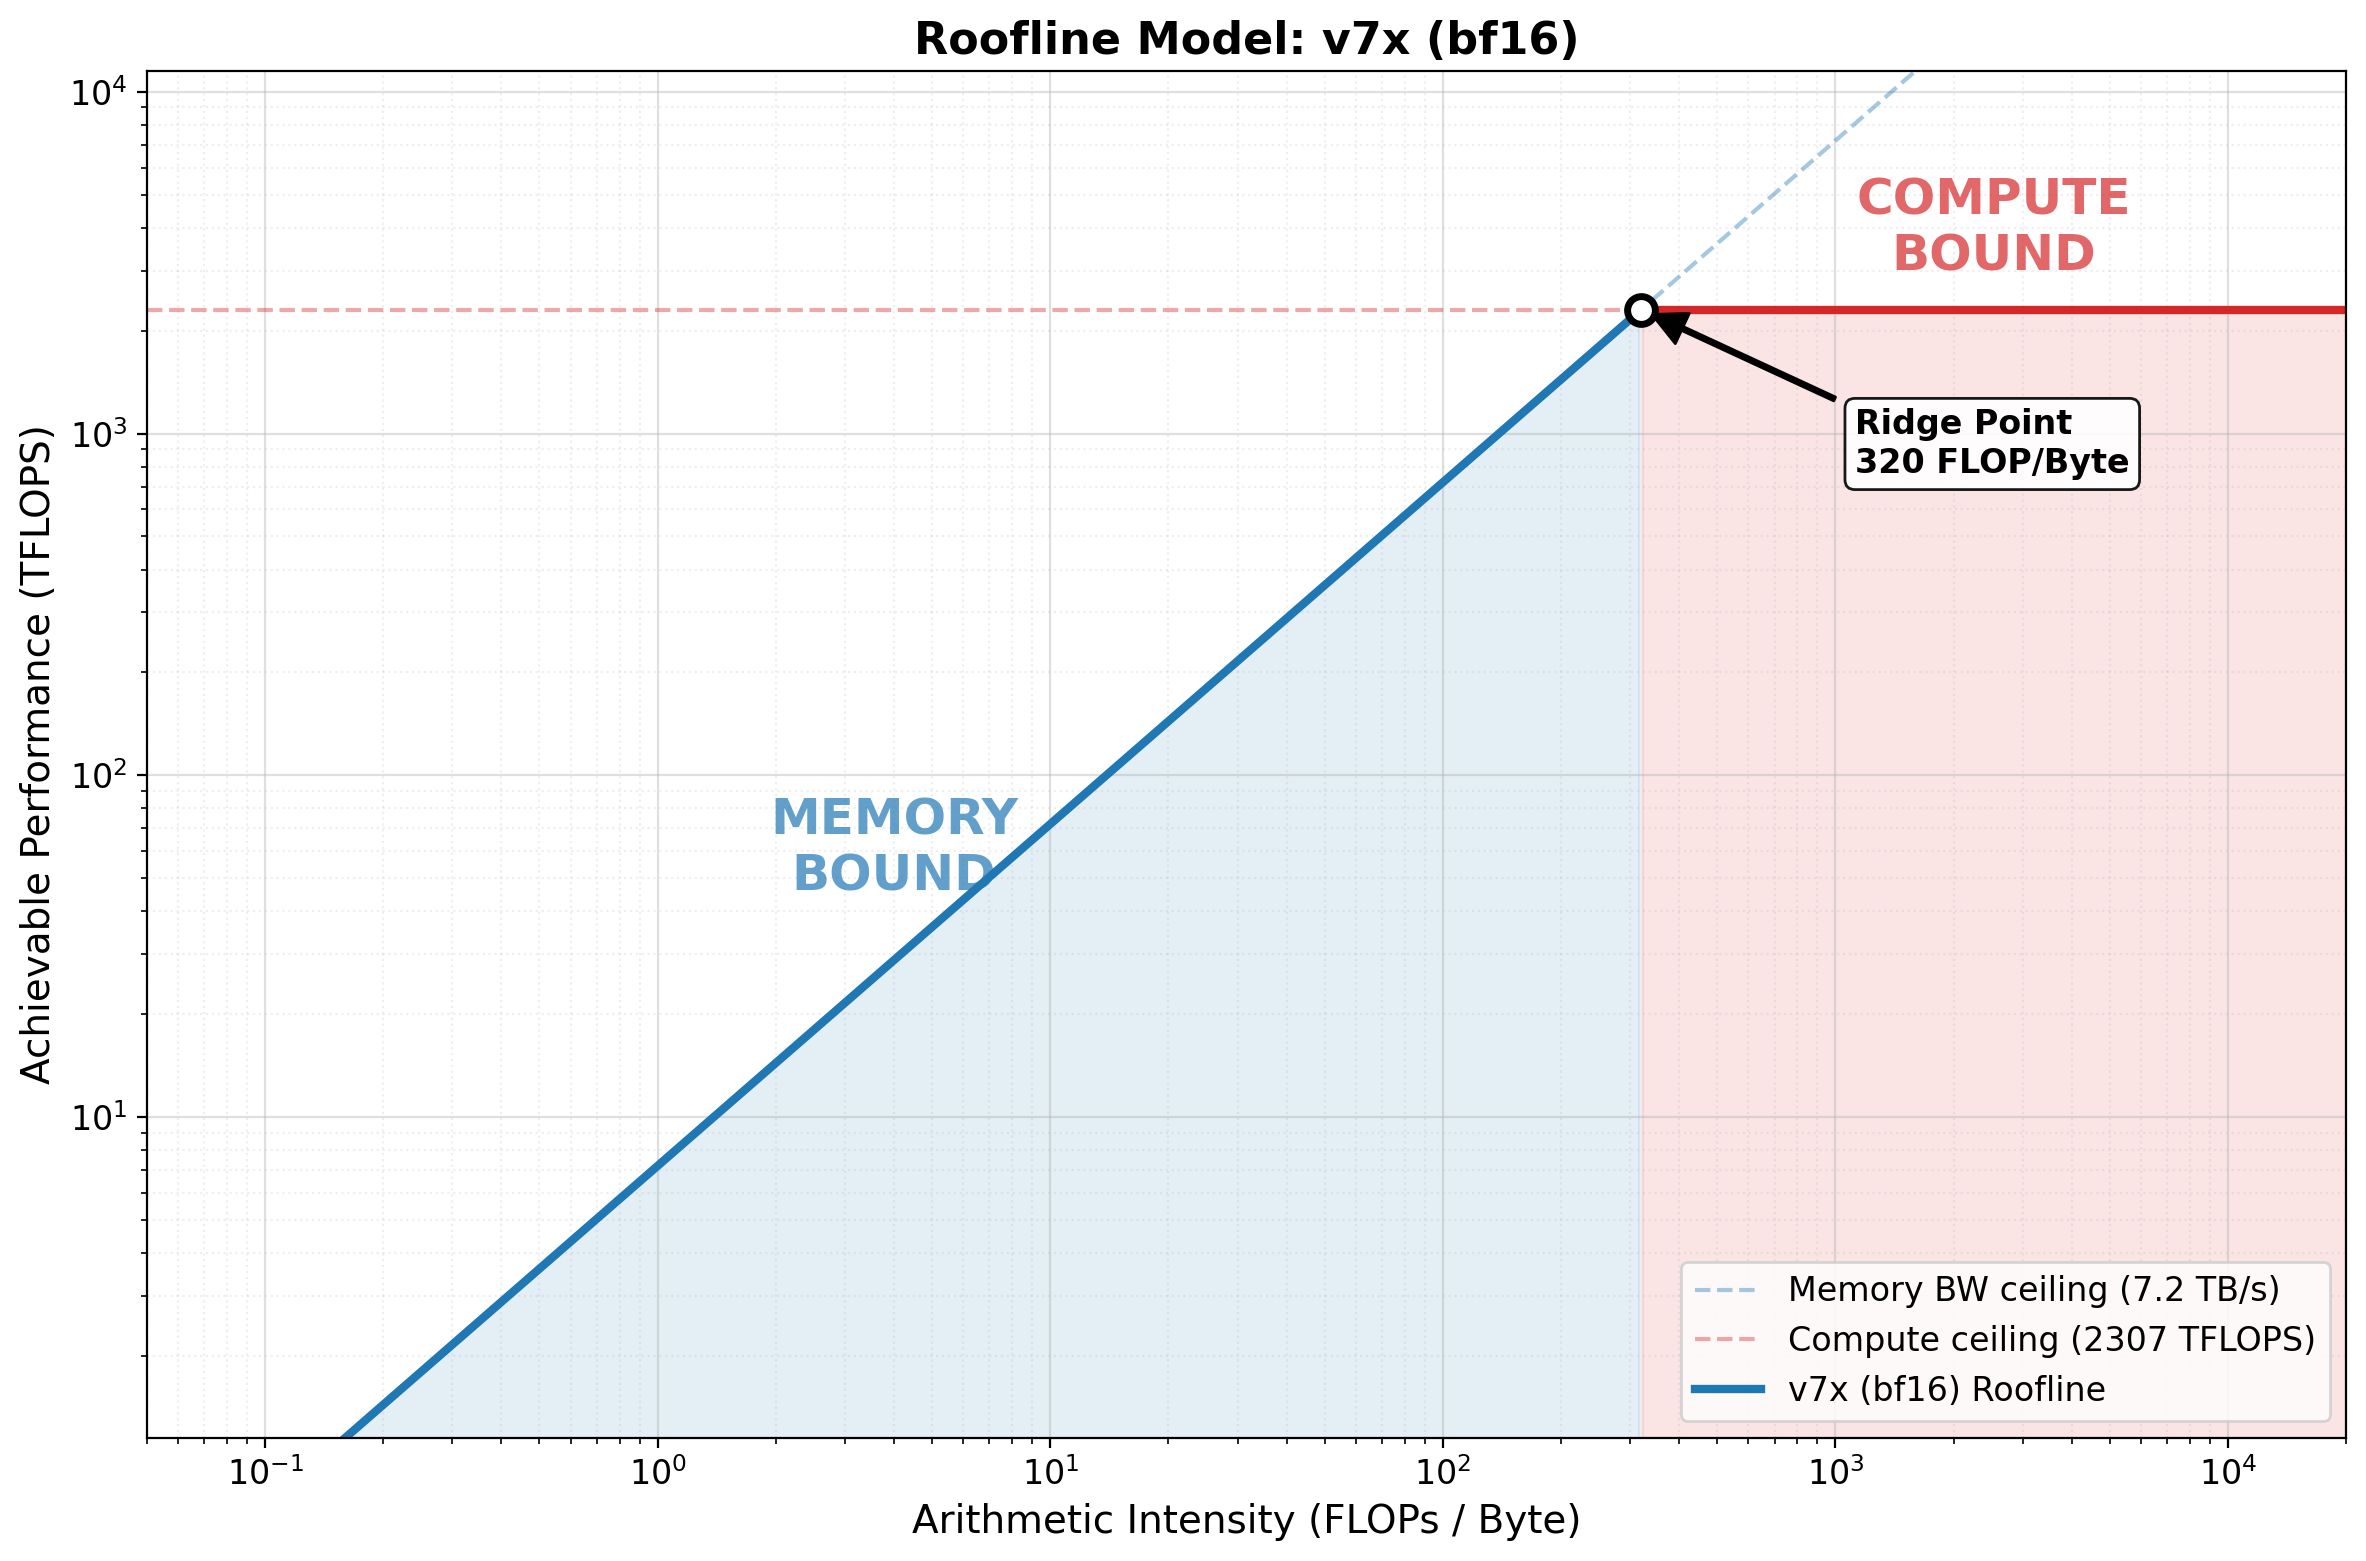

The shaded region is where real kernels live.
Everything ON the roofline line is the theoretical maximum at that AI.
Everything BELOW it represents optimization headroom.


In [ ]:
# @title Anatomy: Single-Chip Roofline { display-mode: "form" }

def plot_single_roofline(spec_name="v7x (bf16)", ai_range=(0.05, 20000)):
    """Plot a single roofline with labeled regions."""
    spec = HW_SPECS[spec_name]
    peak_flops, peak_bw = spec["peak_flops"], spec["peak_bw"]
    ridge = spec["ridge"]

    fig, ax = plt.subplots(figsize=(12, 8))
    ai = np.logspace(np.log10(ai_range[0]), np.log10(ai_range[1]), 1000)

    # Ceilings
    mem_ceiling = ai * peak_bw
    comp_ceiling = np.full_like(ai, peak_flops)
    roofline = np.minimum(mem_ceiling, comp_ceiling)

    # Dashed ceiling lines (extended beyond roofline for context)
    ax.loglog(ai, mem_ceiling, '--', color='#1f77b4', alpha=0.4, linewidth=1.5,
              label=f'Memory BW ceiling ({peak_bw} TB/s)')
    ax.loglog(ai, comp_ceiling, '--', color='#d62728', alpha=0.4, linewidth=1.5,
              label=f'Compute ceiling ({peak_flops} TFLOPS)')

    # Solid roofline — blue for memory-bound segment, red for compute-bound segment
    mask_mem = ai <= ridge
    mask_comp = ai >= ridge  # overlap at ridge so there's no gap
    ax.loglog(ai[mask_mem], roofline[mask_mem], '-', color='#1f77b4', linewidth=3,
              label=f'{spec_name} Roofline')
    ax.loglog(ai[mask_comp], roofline[mask_comp], '-', color='#d62728', linewidth=3)

    # Shade feasible region BELOW the roofline (where kernels actually live)
    ax.fill_between(ai[mask_mem], 1e-4, roofline[mask_mem], color='#1f77b4', alpha=0.12)
    ax.fill_between(ai[mask_comp], 1e-4, roofline[mask_comp], color='#d62728', alpha=0.12)

    # Region labels — positioned just above each roofline segment
    # Memory bound: place at center of memory-bound segment in log-space, just above the line
    mem_label_x = 10**((np.log10(ai_range[0]) + np.log10(ridge)) / 2)
    mem_label_y = mem_label_x * peak_bw * 1.6  # just above the BW line at that x
    ax.text(mem_label_x, mem_label_y, "MEMORY\nBOUND",
            color='#1f77b4', fontweight='bold', fontsize=18, ha='center', alpha=0.7)

    # Compute bound: place at center of compute-bound segment in log-space, just above the line
    comp_label_x = 10**((np.log10(ridge) + np.log10(ai_range[1])) / 2)
    comp_label_y = peak_flops * 1.3  # just above the flat compute ceiling
    ax.text(comp_label_x, comp_label_y, "COMPUTE\nBOUND",
            color='#d62728', fontweight='bold', fontsize=18, ha='center', alpha=0.7)

    # Ridge point
    ax.plot(ridge, peak_flops, 'o', color='black', markersize=10,
            markerfacecolor='white', markeredgewidth=2.5, zorder=5)
    ax.annotate(f'Ridge Point\n{ridge:.0f} FLOP/Byte',
                xy=(ridge, peak_flops),
                xytext=(ridge * 3.5, peak_flops / 3),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9))

    # Formatting
    ax.set_xlabel('Arithmetic Intensity (FLOPs / Byte)', fontsize=14)
    ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=14)
    ax.set_title(f'Roofline Model: {spec_name}', fontsize=16, fontweight='bold')
    ax.set_xlim(ai_range)
    ax.set_ylim(peak_flops * 0.0005, peak_flops * 5.0)
    ax.grid(True, which="major", ls="-", alpha=0.4)
    ax.grid(True, which="minor", ls=":", alpha=0.2)
    ax.legend(loc='lower right', fontsize=12, frameon=True)
    plt.tight_layout()
    return fig, ax

fig, ax = plot_single_roofline()
plt.show()

print("The shaded region is where real kernels live.")
print("Everything ON the roofline line is the theoretical maximum at that AI.")
print("Everything BELOW it represents optimization headroom.")

---

# 3. Hardware Comparison — Where Do Kernels Land?

Now let's overlay all four hardware configurations and place real transformer operations on the plot. Each dot shows the **maximum achievable throughput** for that operation on that hardware.

Key thing to watch: the same operation can be memory-bound on one chip and compute-bound on another.

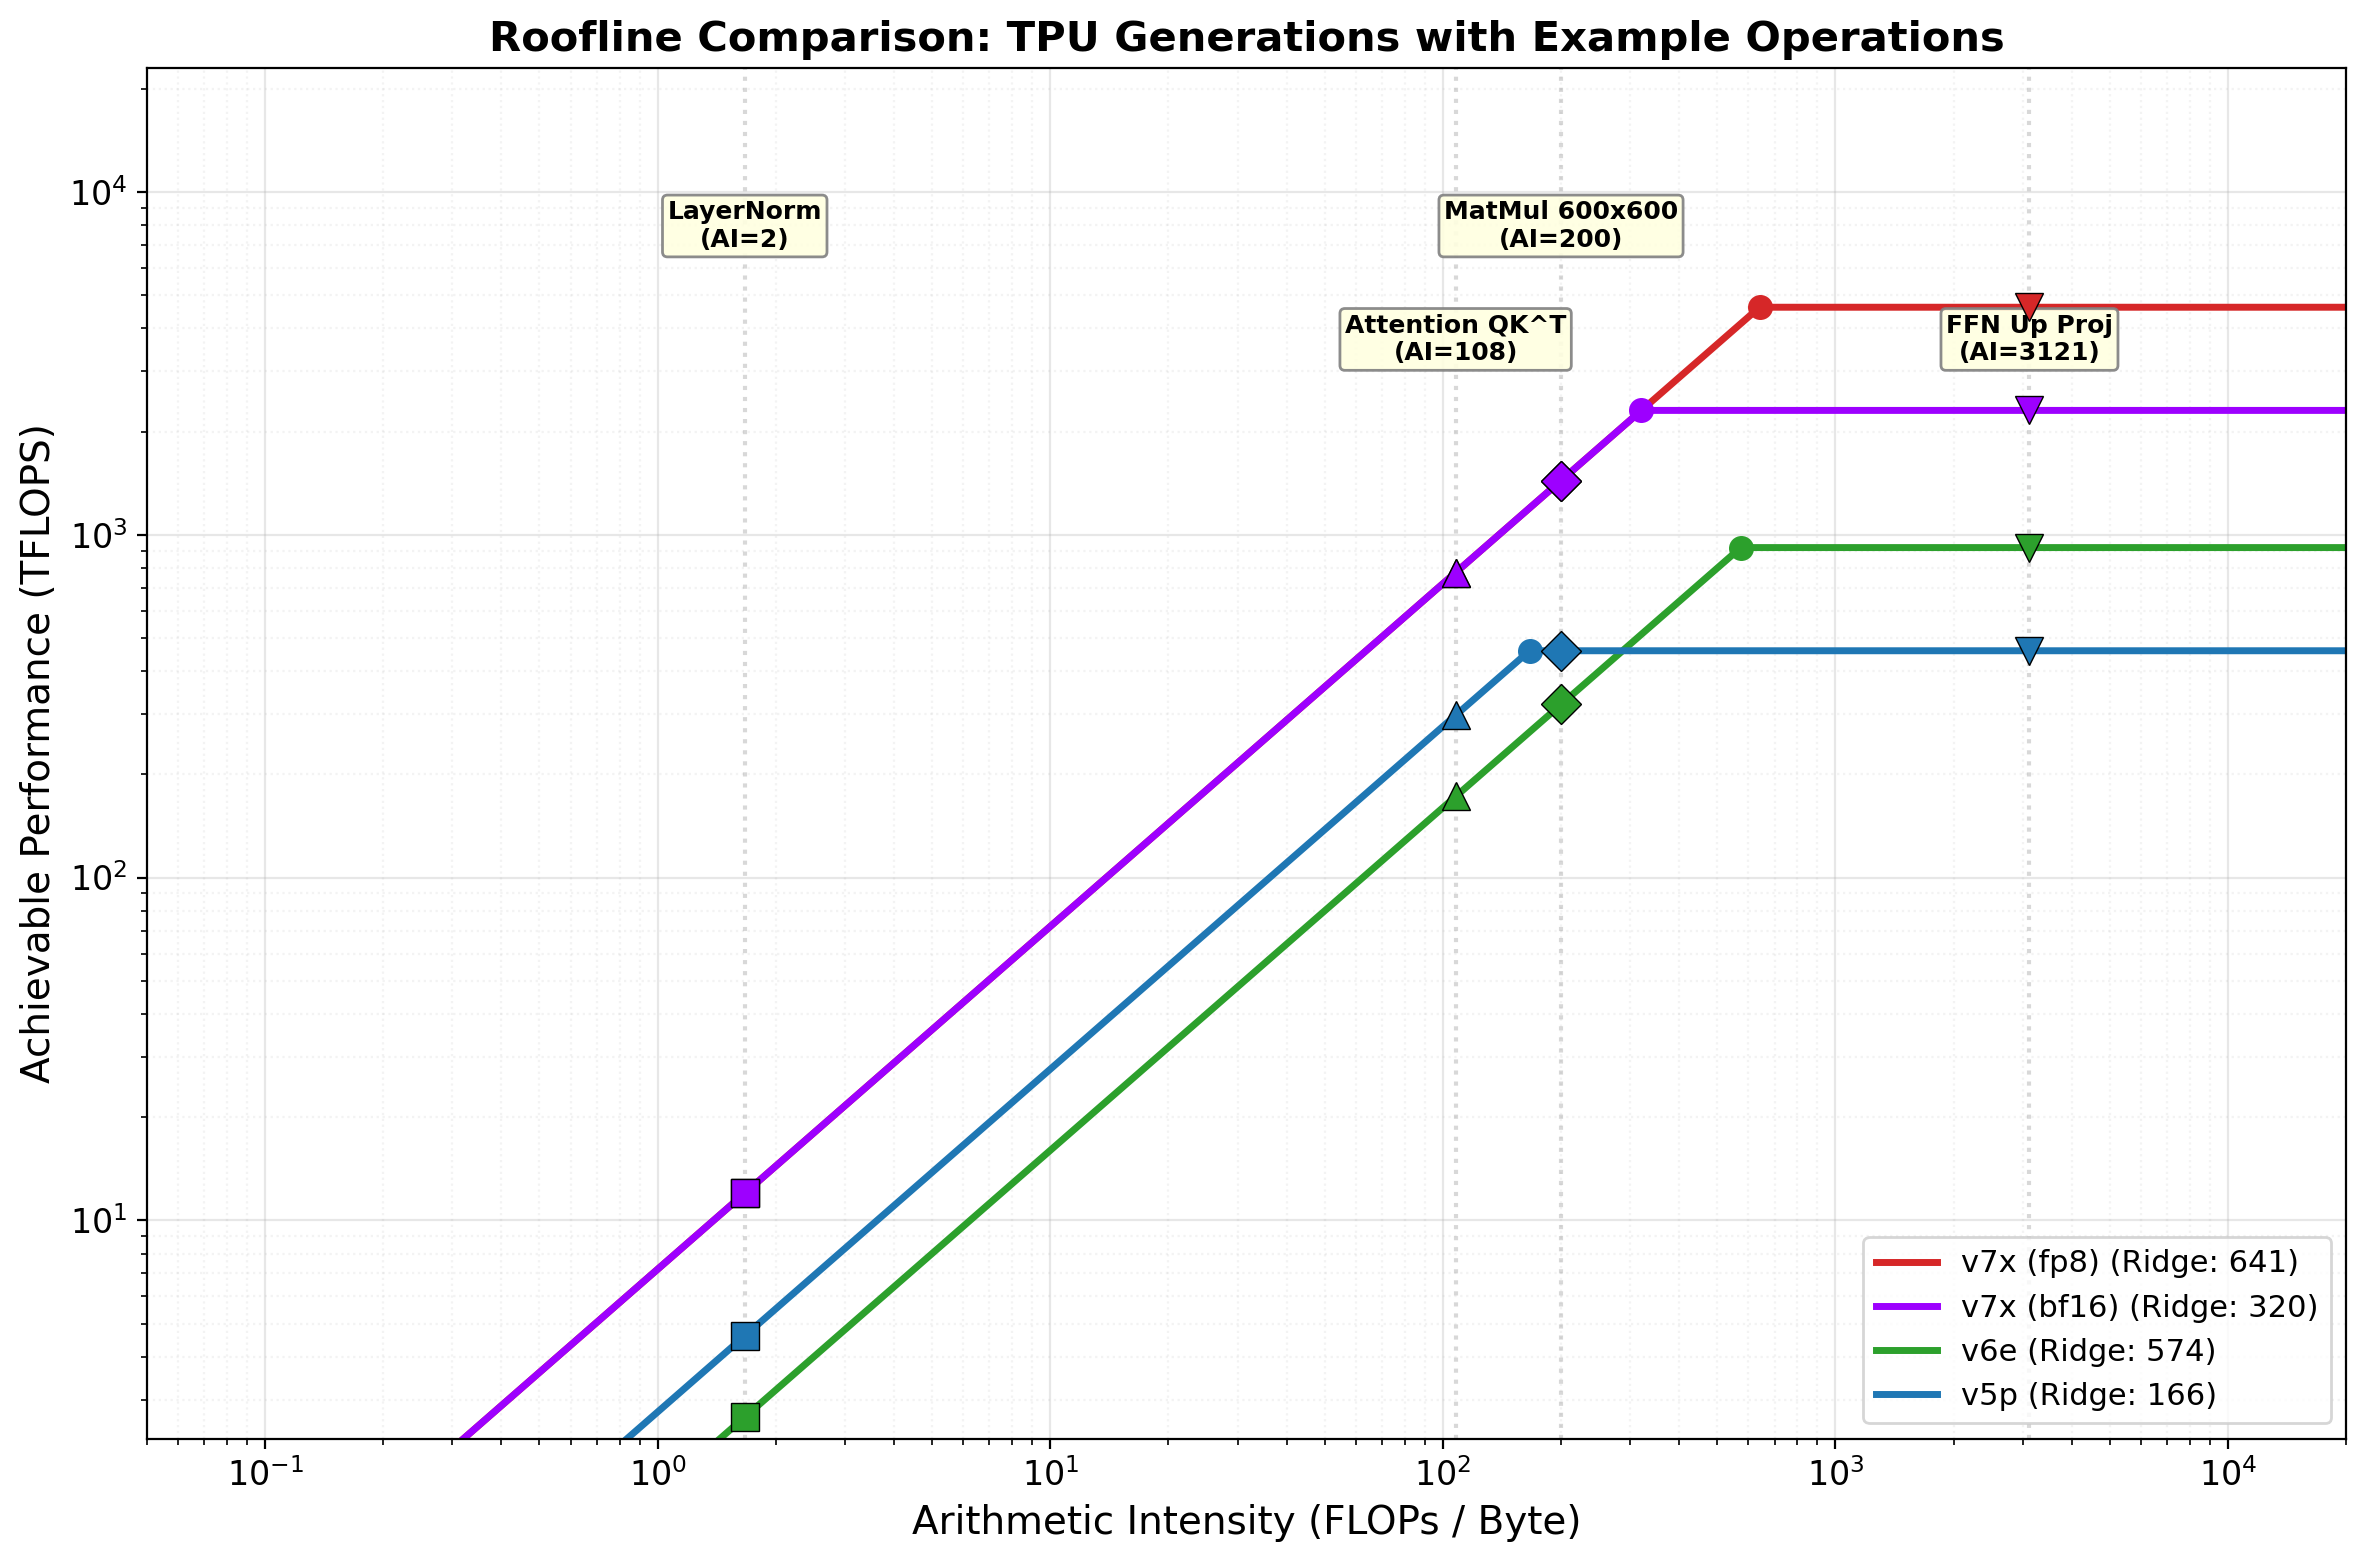


Operation          |     AI |      v7x (fp8)       |      v7x (bf16)      |         v6e          |         v5p          | 
--------------------------------------------------------------------------------------------------------------------------
LayerNorm          |    1.7 |     12T (  0%) MEM   |     12T (  1%) MEM   |      3T (  0%) MEM   |      5T (  1%) MEM   | 
Attention QK^T     |  107.8 |    776T ( 17%) MEM   |    776T ( 34%) MEM   |    172T ( 19%) MEM   |    297T ( 65%) MEM   | 
MatMul 600x600     |  200.0 |   1440T ( 31%) MEM   |   1440T ( 62%) MEM   |    320T ( 35%) MEM   |    459T (100%) COMP  | 
FFN Up Proj        | 3120.8 |   4614T (100%) COMP  |   2307T (100%) COMP  |    918T (100%) COMP  |    459T (100%) COMP  | 


In [ ]:
# @title Multi-Hardware Roofline with Kernel Examples { display-mode: "form" }

def plot_roofline_comparison(hw_specs=HW_SPECS, kernels=None, ai_range=(0.05, 20000)):
    """
    Plot rooflines for multiple hardware configs with kernel examples as dots.

    kernels: list of (name, ai_value) tuples
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    ai = np.logspace(np.log10(ai_range[0]), np.log10(ai_range[1]), 1000)
    max_flops = max(s['peak_flops'] for s in hw_specs.values())

    # Plot each hardware's roofline
    for hw_name, spec in hw_specs.items():
        mem_bound = ai * spec['peak_bw']
        comp_bound = np.full_like(ai, spec['peak_flops'])
        roofline = np.minimum(mem_bound, comp_bound)
        ax.loglog(ai, roofline, '-', linewidth=2.5, color=spec['color'],
                  label=f"{hw_name} (Ridge: {spec['ridge']:.0f})")
        ax.plot(spec['ridge'], spec['peak_flops'], 'o', color=spec['color'], markersize=8)

    # Plot kernel examples as dots on each roofline
    if kernels:
        kernel_markers = ['s', '^', 'D', 'v', 'P', '*']
        for k_idx, (k_name, k_ai) in enumerate(kernels):
            marker = kernel_markers[k_idx % len(kernel_markers)]
            ax.axvline(x=k_ai, color='gray', linestyle=':', alpha=0.3)

            for hw_name, spec in hw_specs.items():
                perf = roofline_perf(k_ai, spec['peak_flops'], spec['peak_bw'])
                ax.plot(k_ai, perf, marker, color=spec['color'], markersize=10,
                        markeredgecolor='black', markeredgewidth=0.5, zorder=5)

            # Stagger labels: even indices at top, odd indices slightly lower
            y_label = max_flops * (1.5 if k_idx % 2 == 0 else 0.7)
            ax.text(k_ai, y_label, f"{k_name}\n(AI={k_ai:.0f})",
                    ha='center', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", ec="gray", alpha=0.9))

    ax.set_xlabel('Arithmetic Intensity (FLOPs / Byte)', fontsize=14)
    ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=14)
    ax.set_title('Roofline Comparison: TPU Generations with Example Operations', fontsize=15, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.set_xlim(ai_range)
    ax.set_ylim(max_flops * 0.0005, max_flops * 5.0)
    ax.grid(True, which="major", ls="-", alpha=0.3)
    ax.grid(True, which="minor", ls=":", alpha=0.15)
    plt.tight_layout()
    return fig, ax


# --- Example kernels with good separation on the log x-axis ---
batch, seq_len, hidden, heads = 32, 2048, 4096, 32
head_dim = hidden // heads

example_kernels = [
    ("LayerNorm",        calculate_ai_layernorm(hidden, batch * seq_len)),         # AI ~ 1.7
    ("Attention QK^T",   calculate_ai_matmul(batch * heads, seq_len, head_dim)['ai']),  # AI ~ 108
    # 600x600 matmul: AI ~ 200, falls BETWEEN v5p ridge (166) and v7x bf16 ridge (320)
    ("MatMul 600x600",   calculate_ai_matmul(600, 600, 600)['ai']),                # AI ~ 200
    ("FFN Up Proj",      calculate_ai_matmul(batch * seq_len, 4 * hidden, hidden)['ai']),  # AI ~ 3121
]

fig, ax = plot_roofline_comparison(kernels=example_kernels)
plt.show()

cw = 20
print(f"\n{'Operation':<18} | {'AI':>6} | ", end="")
for hw_name in HW_SPECS:
    print(f"{hw_name:^{cw}} | ", end="")
print()
print("-" * (30 + (cw + 3) * len(HW_SPECS)))
for k_name, k_ai in example_kernels:
    print(f"{k_name:<18} | {k_ai:>6.1f} | ", end="")
    for hw_name, spec in HW_SPECS.items():
        perf = roofline_perf(k_ai, spec['peak_flops'], spec['peak_bw'])
        pct = perf / spec['peak_flops'] * 100
        bound = "MEM " if k_ai < spec['ridge'] else "COMP"
        cell = f"{perf:>5.0f}T ({pct:>3.0f}%) {bound}"
        print(f"{cell:^{cw}} | ", end="")
    print()

---

# 4. Arithmetic Intensity — What Moves You on the X-Axis?

## The Formula

$$\text{AI} = \frac{\text{Floating Point Operations}}{\text{Bytes Transferred (HBM)}}$$

## What Counts?

| Component | What to Count | Watch Out For |
|-----------|--------------|---------------|
| **FLOPs** | Each multiply and add | Some tools count fused-multiply-add (FMA) as 1 op |
| **Bytes** | Data moved between HBM and compute | Which memory level? Always clarify HBM vs SRAM |

For matrix multiply `C[M,N] = A[M,K] @ B[K,N]`:
- **FLOPs** = `2 * M * N * K`
- **Bytes** = `(M*K + K*N + M*N) * dtype_bytes`
- **AI** = `2*M*N*K / ((M*K + K*N + M*N) * dtype_bytes)`

For square matrices (N x N), this simplifies to AI = `2N / (3 * dtype_bytes)` = **N/3** for bf16.

In [ ]:
# @title How does matrix size affect AI? { display-mode: "form" }


print("Square MatMul AI (bf16, dtype=2 bytes):")
print(f"{'N':>8} | {'FLOPs':>22} | {'Bytes':>15} | {'AI':>8} | Approx N/3")
print("-" * 78)
for n in [64, 256, 1024, 4096, 16384]:
    result = calculate_ai_matmul(n, n, n, dtype_bytes=2)
    approx = n / 3
    print(f"{n:>8} | {result['flops']:>22,} | {result['bytes']:>15,} | {result['ai']:>8.1f} | {approx:.1f}")

print("\nFor square matmuls, AI ~ N/3.")
print("This means a 1000x1000 matmul has AI ~ 333, and a 100x100 has AI ~ 33.")

Square MatMul AI (bf16, dtype=2 bytes):
       N |                  FLOPs |           Bytes |       AI | Approx N/3
------------------------------------------------------------------------------
      64 |                524,288 |          24,576 |     21.3 | 21.3
     256 |             33,554,432 |         393,216 |     85.3 | 85.3
    1024 |          2,147,483,648 |       6,291,456 |    341.3 | 341.3
    4096 |        137,438,953,472 |     100,663,296 |   1365.3 | 1365.3
   16384 |      8,796,093,022,208 |   1,610,612,736 |   5461.3 | 5461.3

For square matmuls, AI ~ N/3.
This means a 1000x1000 matmul has AI ~ 333, and a 100x100 has AI ~ 33.


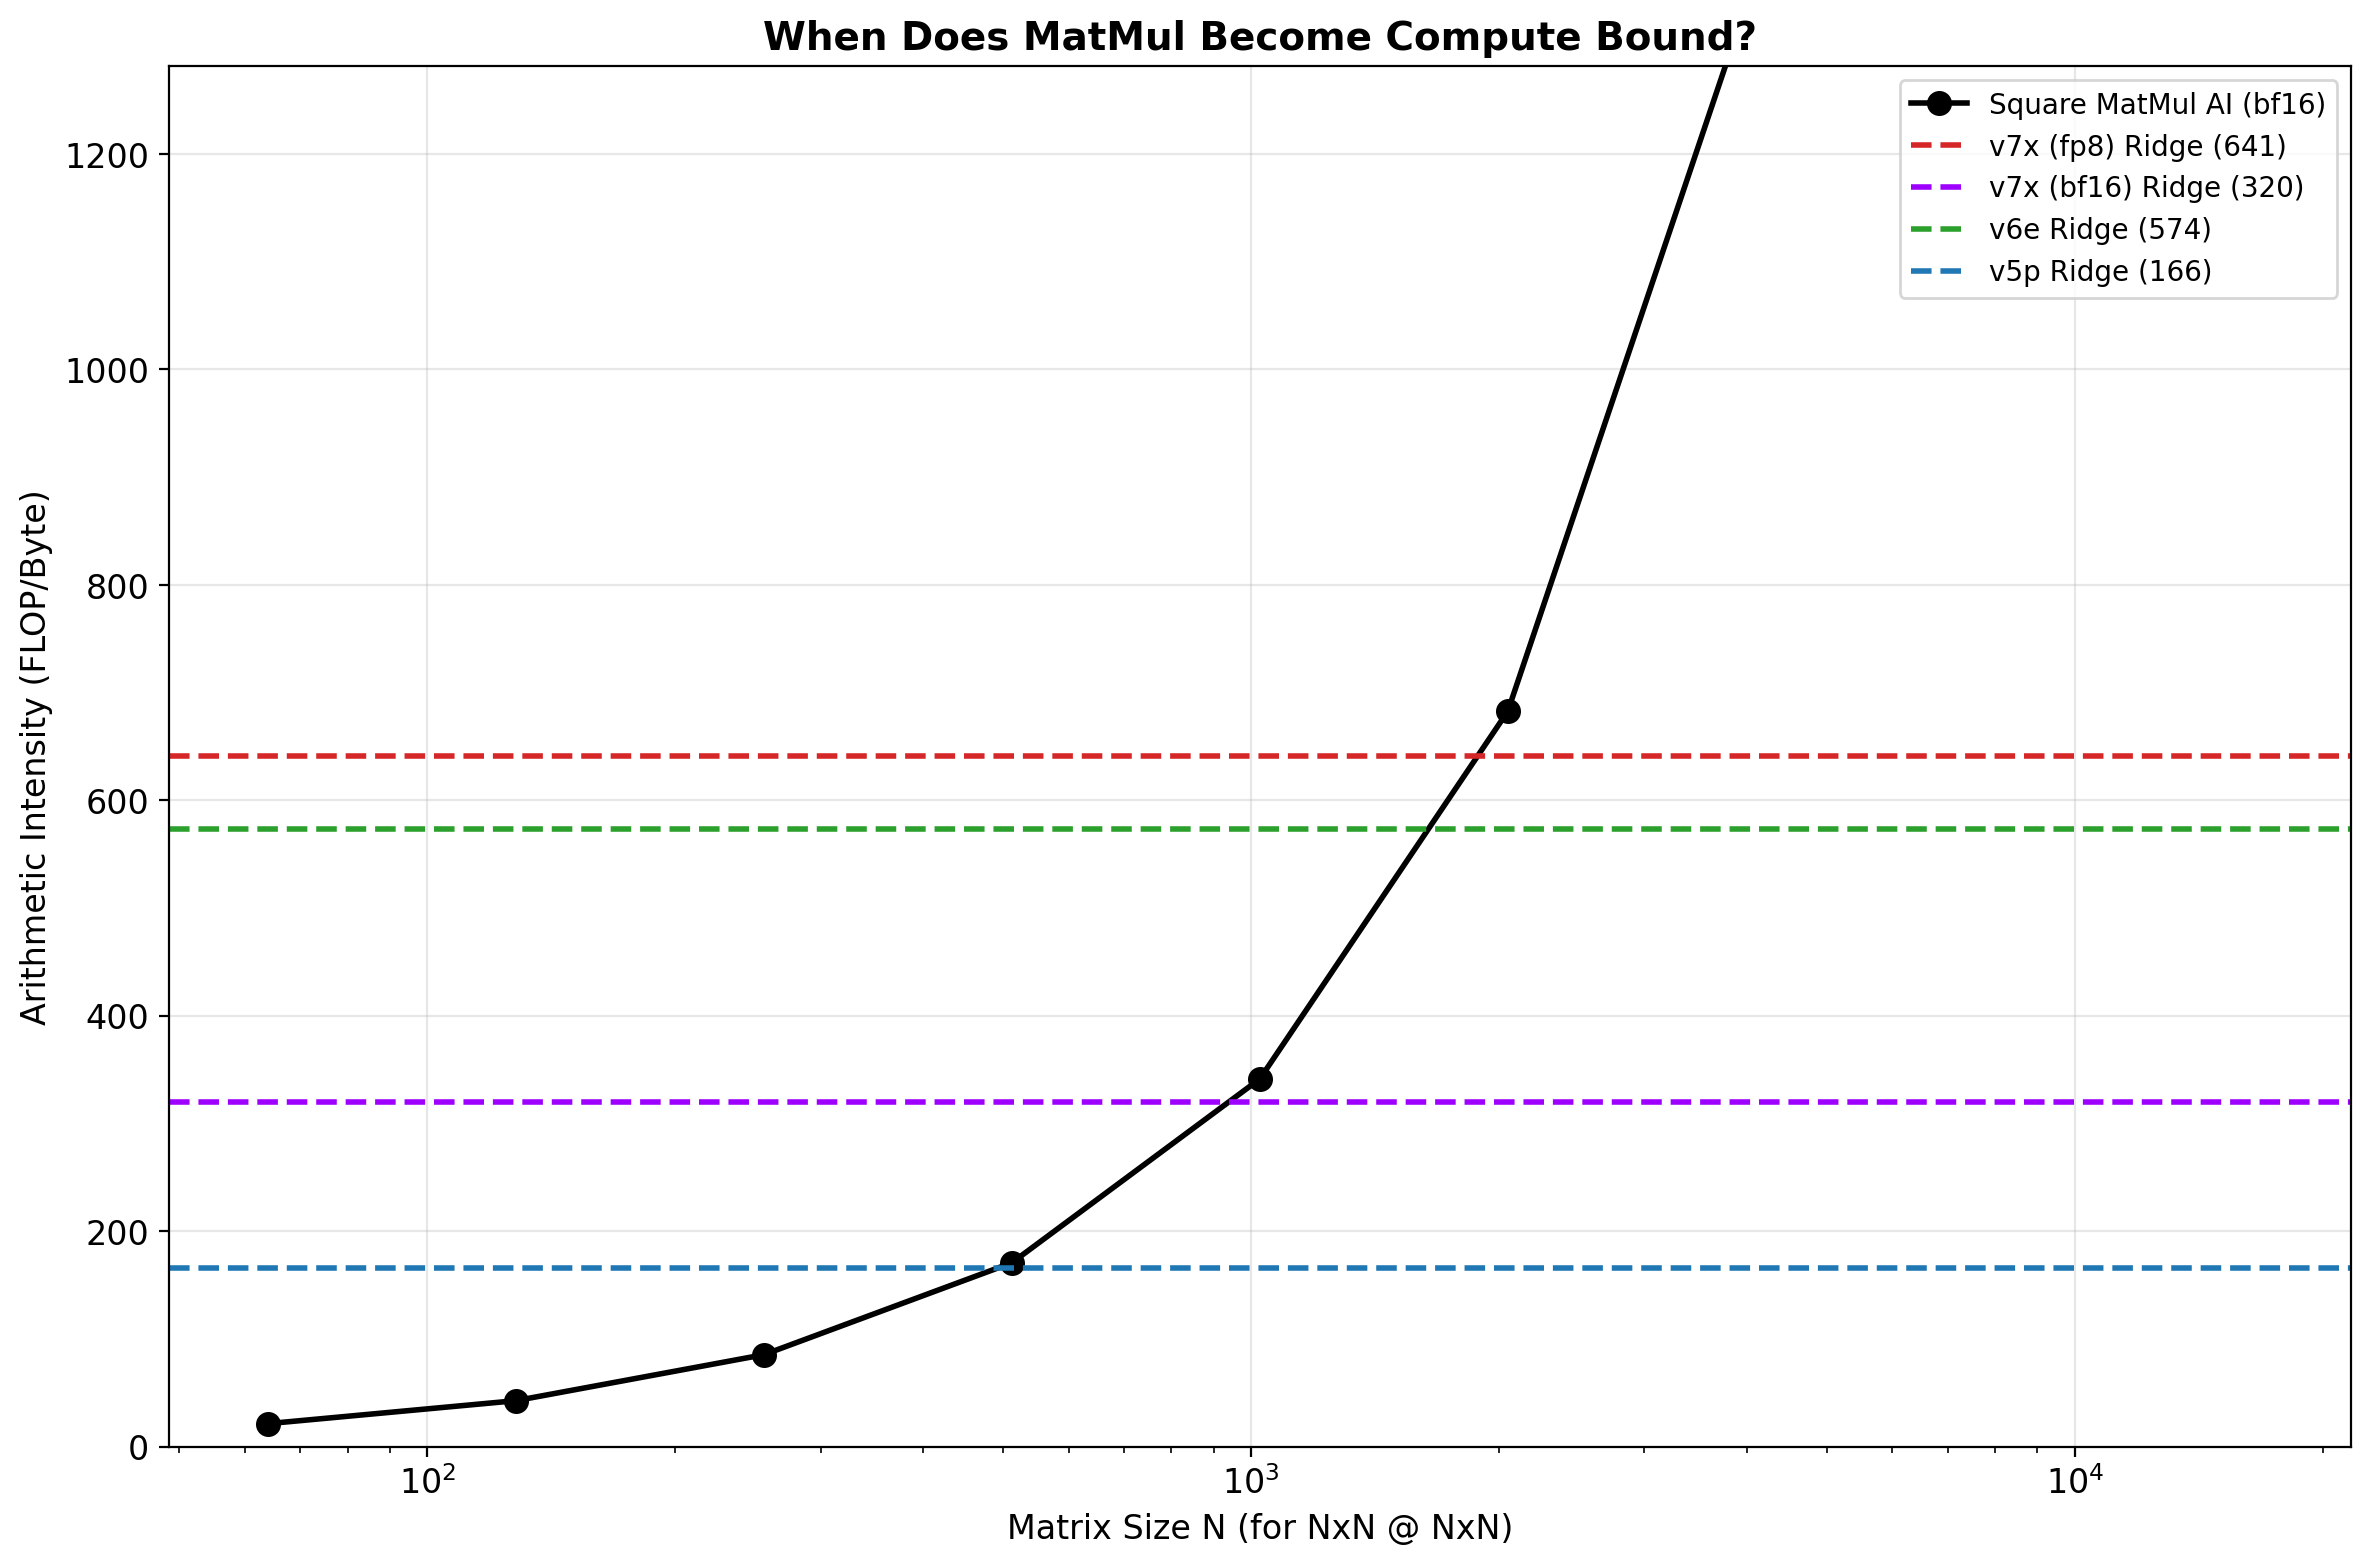


Read it like this: where the black line crosses a dashed line,
that matmul transitions from memory-bound to compute-bound on that hardware.

  v7x (fp8) (ridge 641): compute-bound at N ~ 1922+

  v7x (bf16) (ridge 320): compute-bound at N ~ 961+

  v6e (ridge 574): compute-bound at N ~ 1721+

  v5p (ridge 166): compute-bound at N ~ 498+


In [ ]:
# @title MatMul AI vs Hardware Ridge Points { display-mode: "form" }

sizes = np.array([64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384])
ais_square = [calculate_ai_matmul(n, n, n)['ai'] for n in sizes]

fig, ax = plt.subplots(figsize=(12, 8))
ax.semilogx(sizes, ais_square, 'k-o', linewidth=2, markersize=8, label='Square MatMul AI (bf16)')

# Plot ridge lines with better visibility
for name, spec in HW_SPECS.items():
    ax.axhline(y=spec['ridge'], color=spec['color'], linestyle='--', linewidth=2,
               label=f"{name} Ridge ({spec['ridge']:.0f})")

# Tighter y-axis to see the separation between ridges
max_ridge = max(spec['ridge'] for spec in HW_SPECS.values())
ax.set_ylim(0, max_ridge * 2.0)

ax.set_xlabel('Matrix Size N (for NxN @ NxN)', fontsize=12)
ax.set_ylabel('Arithmetic Intensity (FLOP/Byte)', fontsize=12)
ax.set_title('When Does MatMul Become Compute Bound?', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRead it like this: where the black line crosses a dashed line,")
print("that matmul transitions from memory-bound to compute-bound on that hardware.")
for name, spec in HW_SPECS.items():
    approx_n = int(spec['ridge'] * 3)
    print(f"\n  {name} (ridge {spec['ridge']:.0f}): compute-bound at N ~ {approx_n}+")

## Why Fusion Matters: Moving on the X-Axis

The roofline's x-axis (arithmetic intensity) isn't a fixed property of an operation — it depends on how operations are *scheduled*. When the compiler fuses multiple memory-bound ops into a single kernel, it eliminates intermediate HBM reads/writes, increasing AI without changing the math. This is the single most impactful optimization for memory-bound workloads.

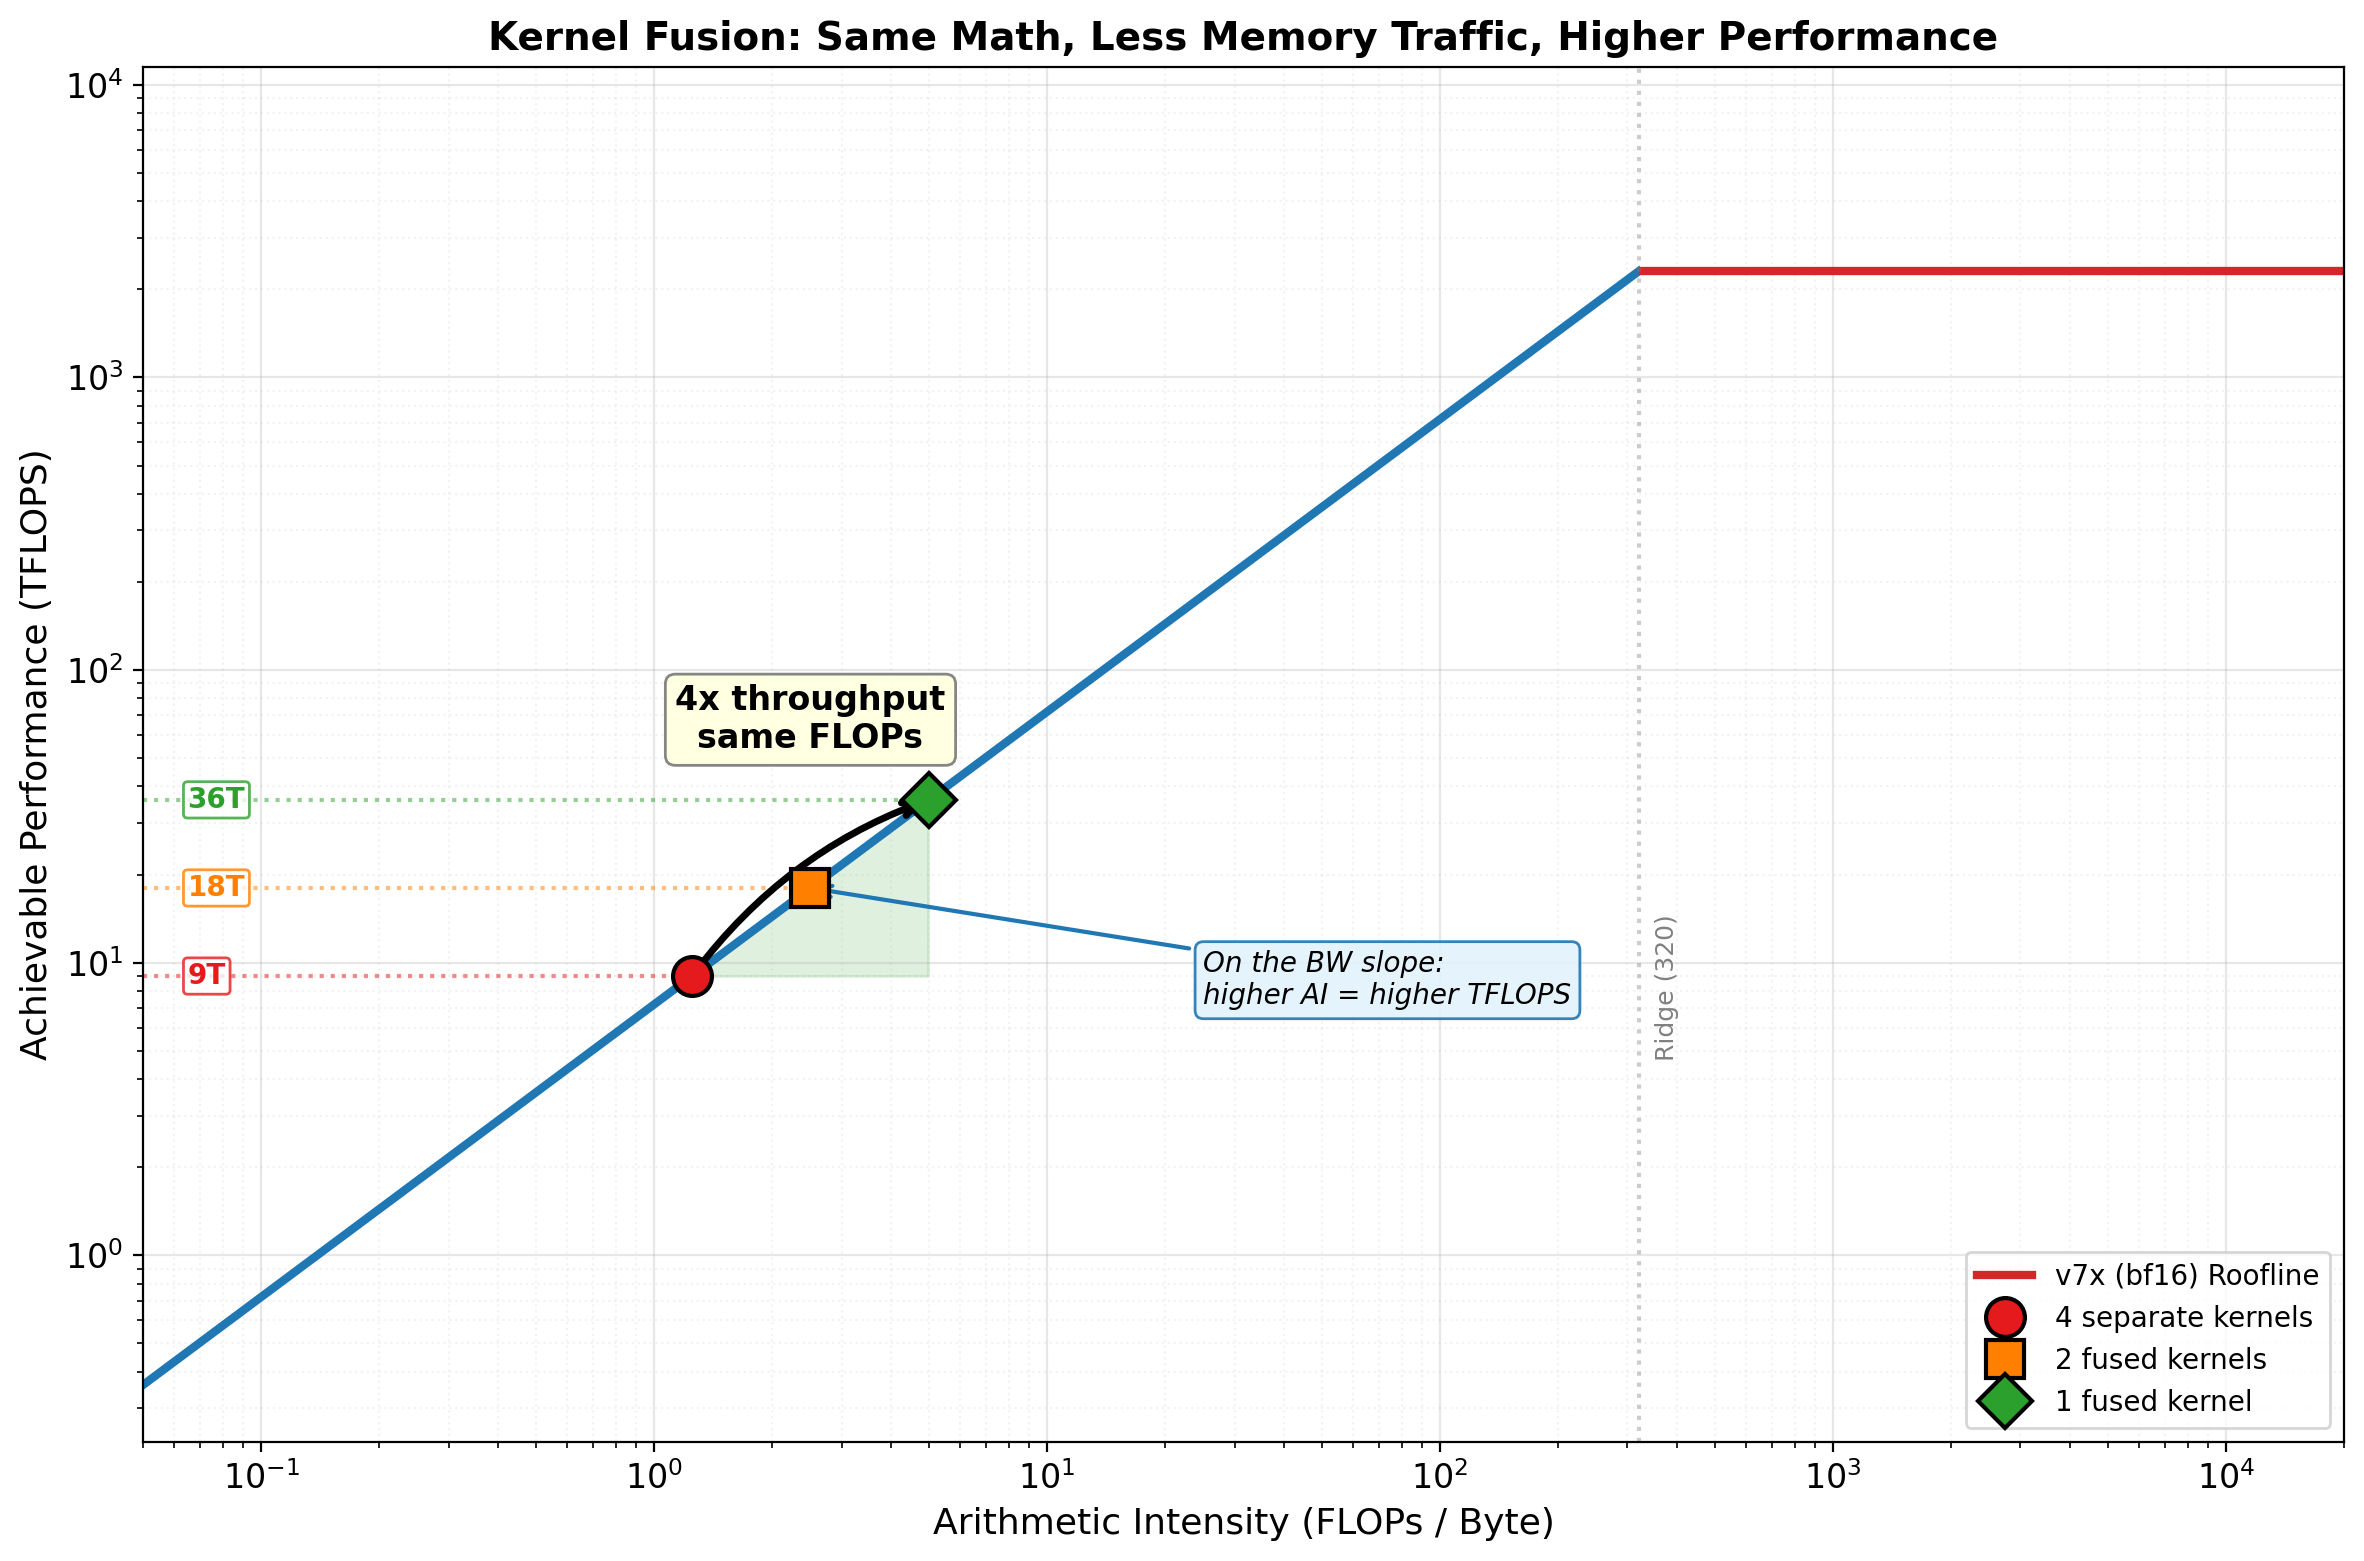

Scenario: LayerNorm -> GELU -> Dropout -> Residual Add
  Elements: 268,435,456 (batch=32, seq=2048, hidden=4096)

  Strategy               |  HBM Traffic |       AI |  Roofline Perf |  Speedup
  ----------------------------------------------------------------------------
  4 separate kernels     |      4.29 GB |      1.2 |        9.0 TFLOPS |     1.0x
  2 fused kernels        |      2.15 GB |      2.5 |       18.0 TFLOPS |     2.0x
  1 fused kernel         |      1.07 GB |      5.0 |       36.0 TFLOPS |     4.0x

  All three are memory-bound — but that's the point. On the BW slope,
  every 2x reduction in memory traffic is a 2x improvement in throughput.
  Fusion doesn't change the FLOPs — it eliminates redundant HBM round-trips.


In [ ]:
# @title Fusion Impact on the Roofline { display-mode: "form" }

hw = HW_SPECS["v7x (bf16)"]
ai_vals = np.logspace(np.log10(0.05), np.log10(20000), 500)
roofline_vals = np.minimum(ai_vals * hw['peak_bw'], hw['peak_flops'])

fig, ax = plt.subplots(figsize=(12, 8))

# Draw roofline with colored segments
ridge = hw['ridge']
mask_mem = ai_vals <= ridge
mask_comp = ai_vals >= ridge
ax.loglog(ai_vals[mask_mem], roofline_vals[mask_mem], '-', color='#1f77b4', linewidth=3)
ax.loglog(ai_vals[mask_comp], roofline_vals[mask_comp], '-', color='#d62728', linewidth=3,
          label=f'v7x (bf16) Roofline')

# --- Scenario: A transformer block's elementwise tail ---
# Unfused: LayerNorm -> GELU -> Dropout -> Residual Add (4 separate kernels)
# Each reads from HBM and writes back to HBM
num_el = 32 * 2048 * 4096  # batch * seq * hidden
dtype = 2  # bf16
one_rw = 2 * num_el * dtype  # one read + write round trip in bytes

# Unfused: 4 separate kernels, each does a read+write round trip
unfused_flops = num_el * (10 + 8 + 1 + 1)  # LN(10) + GELU(8) + Dropout(1) + Add(1)
unfused_bytes = 4 * one_rw                   # 4 kernels, each reads + writes
unfused_ai = unfused_flops / unfused_bytes

# 2-way fused: (LayerNorm+GELU) and (Dropout+Add) — 2 kernels
fused2_flops = unfused_flops
fused2_bytes = 2 * one_rw
fused2_ai = fused2_flops / fused2_bytes

# Fully fused: all 4 ops in one kernel — 1 read, 1 write
fused4_flops = unfused_flops
fused4_bytes = one_rw
fused4_ai = fused4_flops / fused4_bytes

# Compute roofline performance for each
scenarios = [
    ("4 separate\nkernels", unfused_ai, unfused_bytes, '#e41a1c', 'o', 14),
    ("2 fused\nkernels",    fused2_ai,  fused2_bytes,  '#ff7f00', 's', 14),
    ("1 fused\nkernel",     fused4_ai,  fused4_bytes,  '#2ca02c', 'D', 14),
]
unfused_perf = roofline_perf(unfused_ai, hw['peak_flops'], hw['peak_bw'])
fused4_perf = roofline_perf(fused4_ai, hw['peak_flops'], hw['peak_bw'])

# Shade the performance gain region between unfused and fused on the roofline
shade_mask = (ai_vals >= unfused_ai) & (ai_vals <= fused4_ai)
ax.fill_between(ai_vals[shade_mask], unfused_perf, roofline_vals[shade_mask],
                color='#2ca02c', alpha=0.15)

# Plot each scenario as a dot on the roofline
for label, ai, nbytes, color, marker, ms in scenarios:
    perf = roofline_perf(ai, hw['peak_flops'], hw['peak_bw'])

    # Dot on the roofline
    ax.plot(ai, perf, marker, color=color, markersize=ms,
            markeredgecolor='black', markeredgewidth=1.5, zorder=5, label=label.replace('\n', ' '))

    # Horizontal dashed line to y-axis showing the TFLOPS value
    ax.plot([ai_vals[0], ai], [perf, perf], ':', color=color, alpha=0.5, linewidth=1.5)

    # TFLOPS label on the y-axis side
    ax.text(ai_vals[0] * 1.3, perf, f'{perf:.0f}T', fontsize=10, fontweight='bold',
            color=color, va='center', ha='left',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=color, alpha=0.8))

# Big arrow from unfused to fused with "4x" annotation
ax.annotate('', xy=(fused4_ai, fused4_perf), xytext=(unfused_ai, unfused_perf),
            arrowprops=dict(arrowstyle='->', color='black', lw=2.5,
                            connectionstyle='arc3,rad=-0.15'))
mid_ai = 10**((np.log10(unfused_ai) + np.log10(fused4_ai)) / 2)
mid_perf = 10**((np.log10(unfused_perf) + np.log10(fused4_perf)) / 2)
ax.text(mid_ai, mid_perf * 3, f'4x throughput\nsame FLOPs',
        fontsize=12, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', alpha=0.95))

# Key insight annotation: why moving right = moving up on BW slope
ax.annotate('On the BW slope:\nhigher AI = higher TFLOPS',
            xy=(fused2_ai, roofline_perf(fused2_ai, hw['peak_flops'], hw['peak_bw'])),
            xytext=(fused4_ai * 5, unfused_perf * 0.8),
            fontsize=10, ha='left', style='italic',
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', fc='#e3f2fd', ec='#1f77b4', alpha=0.9))

# Ridge line annotation
ax.axvline(x=ridge, color='gray', linestyle=':', alpha=0.4)
ax.text(ridge * 1.1, hw['peak_flops'] * 0.002, f'Ridge ({ridge:.0f})',
        fontsize=9, color='gray', rotation=90, va='bottom')

ax.set_xlabel('Arithmetic Intensity (FLOPs / Byte)', fontsize=13)
ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=13)
ax.set_title('Kernel Fusion: Same Math, Less Memory Traffic, Higher Performance',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0.05, 20000)
ax.set_ylim(hw['peak_flops'] * 0.0001, hw['peak_flops'] * 5)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.15, linestyle=':')
plt.tight_layout()
plt.show()

# Summary table
print("Scenario: LayerNorm -> GELU -> Dropout -> Residual Add")
print(f"  Elements: {num_el:,} (batch=32, seq=2048, hidden=4096)\n")
print(f"  {'Strategy':<22} | {'HBM Traffic':>12} | {'AI':>8} | {'Roofline Perf':>14} | {'Speedup':>8}")
print(f"  {'-'*76}")
for label, ai, nbytes, _, _, _ in scenarios:
    name = label.replace('\n', ' ')
    perf = roofline_perf(ai, hw['peak_flops'], hw['peak_bw'])
    speedup = perf / unfused_perf
    traffic_gb = nbytes / 1e9
    print(f"  {name:<22} | {traffic_gb:>9.2f} GB | {ai:>8.1f} | {perf:>10.1f} TFLOPS | {speedup:>7.1f}x")
print(f"\n  All three are memory-bound — but that's the point. On the BW slope,")
print(f"  every 2x reduction in memory traffic is a 2x improvement in throughput.")
print(f"  Fusion doesn't change the FLOPs — it eliminates redundant HBM round-trips.")

---

# 5. Measuring FLOPs in JAX

JAX can report FLOPs for compiled functions via `cost_analysis()`. This requires an accelerator backend (TPU or GPU). When the device is unavailable, we fall back to theoretical values.

In [ ]:
# @title Theoretical and JAX-derived values and arithmetic intensity { display-mode: "form" }
import numpy as np

# --- 1. CONFIGURATION ---
n = 2048

# --- 2. THEORETICAL CALCULATIONS ---
# FLOPs: 2 * N^3 (multiply + add)
theoretical_flops = 2 * n**3

# Bytes (Logical HLO Model)
# BF16: Inputs(2) + Accumulator(4, Float32) + Output(2)
theoretical_bytes_bf16 = (n**2 * 2) + (n**2 * 2) + (n**2 * 4) + (n**2 * 2)
# FP8: Inputs(1) + Accumulator(2, Wide/BF16) + Output(1)
theoretical_bytes_fp8 = (n**2 * 1) + (n**2 * 1) + (n**2 * 2) + (n**2 * 1)

theoretical_ai_bf16 = theoretical_flops / theoretical_bytes_bf16
theoretical_ai_fp8 = theoretical_flops / theoretical_bytes_fp8

# --- 3. JAX MEASUREMENTS (If Available) ---
jax_results = {}

# Safely check if HAS_JAX is defined and True
if 'HAS_JAX' in globals() and HAS_JAX:
    try:
        import jax
        import jax.numpy as jnp
        from jax import random, lax

        # Check device
        devices = jax.devices()
        backend = devices[0].platform if devices else "unknown"
        print(f"JAX Backend: {backend} ({len(devices)} devices)")

        def get_jax_cost(fn, *args):
            try:
                lowered = jax.jit(fn).lower(*args)
                compiled = lowered.compile()
                cost = compiled.cost_analysis()
                # 'flops' and 'bytes accessed' are standard keys in cost_analysis
                return cost.get('flops', 0), cost.get('bytes accessed', 0)
            except Exception as e:
                return 0, 0

        # Run Benchmarks
        k = random.PRNGKey(0)
        k1, k2 = random.split(k)

        # BF16
        # lax.dot_general prevents implicit upcasting of inputs which can happen with jnp.dot
        a = random.normal(k1, (n, n), dtype=jnp.bfloat16)
        b = random.normal(k2, (n, n), dtype=jnp.bfloat16)

        def matmul_bf16(lhs, rhs):
            return lax.dot_general(lhs, rhs, dimension_numbers=(((1,), (0,)), ((), ())), preferred_element_type=jnp.bfloat16)

        f_bf16, b_bf16 = get_jax_cost(matmul_bf16, a, b)
        if f_bf16 > 0:
            jax_results['bf16'] = {'flops': f_bf16, 'bytes': b_bf16}

        # FP8 (Check availability)
        if hasattr(jnp, 'float8_e4m3fn'):
            c = random.normal(k1, (n, n), dtype=jnp.float8_e4m3fn)
            d = random.normal(k2, (n, n), dtype=jnp.float8_e4m3fn)

            def matmul_fp8(lhs, rhs):
                return lax.dot_general(lhs, rhs, dimension_numbers=(((1,), (0,)), ((), ())), preferred_element_type=jnp.float8_e4m3fn)

            f_fp8, b_fp8 = get_jax_cost(matmul_fp8, c, d)
            if f_fp8 > 0:
                jax_results['fp8'] = {'flops': f_fp8, 'bytes': b_fp8}

    except Exception as e:
        print(f"JAX execution skipped/failed: {e}")
else:
    print("JAX not found. Using theoretical values only.")

# --- 4. RESULTS TABLE ---
print(f"\nMatMul: {n}x{n} @ {n}x{n}")
print(f"\n  {'':>10} {'Theor.(bf16)':>14} {'JAX (bf16)':>14} {'Theor.(fp8)':>14} {'JAX (fp8)':>14}")
print(f"  {'-'*72}")

# Helper to format
def fmt_val(val, is_int=True):
    if val is None or val == 0: return f"{'n/a':>14}"
    return f"{int(val):>14,}" if is_int else f"{val:>14.1f}"

# Extract values
jax_bf16_f = jax_results.get('bf16', {}).get('flops', 0)
jax_bf16_b = jax_results.get('bf16', {}).get('bytes', 0)
jax_fp8_f = jax_results.get('fp8', {}).get('flops', 0)
jax_fp8_b = jax_results.get('fp8', {}).get('bytes', 0)

# Rows
print(f"  {'FLOPs':>10} {fmt_val(theoretical_flops)} {fmt_val(jax_bf16_f)} {fmt_val(theoretical_flops)} {fmt_val(jax_fp8_f)}")
print(f"  {'Bytes':>10} {fmt_val(theoretical_bytes_bf16)} {fmt_val(jax_bf16_b)} {fmt_val(theoretical_bytes_fp8)} {fmt_val(jax_fp8_b)}")

jax_ai_bf16 = jax_bf16_f / jax_bf16_b if jax_bf16_b else 0
jax_ai_fp8 = jax_fp8_f / jax_fp8_b if jax_fp8_b else 0

print(f"  {'AI':>10} {fmt_val(theoretical_ai_bf16, False)} {fmt_val(jax_ai_bf16, False)} {fmt_val(theoretical_ai_fp8, False)} {fmt_val(jax_ai_fp8, False)}")

# --- Analysis Text ---
print("\n" + "="*84)
print(" ANALYSIS: LOGICAL HLO COST MODEL")
print("-" * 84)
print(f" To align Theory with JAX's cost_analysis(), we model the 'Accumulator Tax'.")
print(f" JAX counts the intermediate writes to the Accumulator, even if hardware fuses them.\n")

print(f" 1. FLOPs = 2 * N^3")
print(f"          = 2 * {n}^3")
print(f"          = {theoretical_flops:,}")
print("")
print(f" 2. Bytes_bf16 = N^2 * (Size(A) + Size(B) + Size(Acc_F32) + Size(Out))")
print(f"               = {n}^2 * (2 + 2 + 4 + 2)")
print(f"               = {theoretical_bytes_bf16:,}")
print("")
print(f" 3. Bytes_fp8 = N^2 * (Size(A) + Size(B) + Size(Acc_Wide) + Size(Out))")
print(f"              = {n}^2 * (1 + 1 + 2 + 1)")
print(f"              = {theoretical_bytes_fp8:,}")
print("="*84)

JAX not found. Using theoretical values only.

MatMul: 2048x2048 @ 2048x2048

               Theor.(bf16)     JAX (bf16)    Theor.(fp8)      JAX (fp8)
  ------------------------------------------------------------------------
       FLOPs 17,179,869,184            n/a 17,179,869,184            n/a
       Bytes     41,943,040            n/a     20,971,520            n/a
          AI          409.6            n/a          819.2            n/a

 ANALYSIS: LOGICAL HLO COST MODEL
------------------------------------------------------------------------------------
 To align Theory with JAX's cost_analysis(), we model the 'Accumulator Tax'.
 JAX counts the intermediate writes to the Accumulator, even if hardware fuses them.

 1. FLOPs = 2 * N^3
          = 2 * 2048^3
          = 17,179,869,184

 2. Bytes_bf16 = N^2 * (Size(A) + Size(B) + Size(Acc_F32) + Size(Out))
               = 2048^2 * (2 + 2 + 4 + 2)
               = 41,943,040

 3. Bytes_fp8 = N^2 * (Size(A) + Size(B) + Size(Acc_Wide) +

---

# 6. Common Misconceptions

These are mistakes even experienced engineers make when interpreting rooflines.

## Misconception: "My kernel only hits 3% of peak FLOPS — it must be poorly optimized"

If your kernel is **memory-bound**, peak FLOPS is simply the wrong yardstick. A memory-bound kernel's performance is limited by bandwidth, not compute. Measuring it against peak FLOPS is like judging a truck's speed against a sports car's top speed — they're playing different games.

In [ ]:
# @title A "slow" kernel that's actually well-optimized { display-mode: "form" }

# Consider LayerNorm on v7x (bf16)
hw = HW_SPECS["v7x (bf16)"]
ai_layernorm = calculate_ai_layernorm(4096, 32 * 2048)  # hidden=4096, batch*seq=65536

# What the roofline predicts
max_perf = roofline_perf(ai_layernorm, hw['peak_flops'], hw['peak_bw'])
pct_peak_flops = max_perf / hw['peak_flops'] * 100
pct_peak_bw = (max_perf / ai_layernorm) / hw['peak_bw'] * 100  # effective BW utilization

print(f"LayerNorm on v7x (bf16):")
print(f"  Arithmetic Intensity:  {ai_layernorm:.1f} FLOP/Byte")
print(f"  Ridge Point:           {hw['ridge']:.0f} FLOP/Byte")
print(f"  Status:                {'MEMORY BOUND' if ai_layernorm < hw['ridge'] else 'COMPUTE BOUND'}")
print()
print(f"  Roofline max perf:     {max_perf:.1f} TFLOPS")
print(f"  % of peak FLOPS:       {pct_peak_flops:.1f}%    <-- looks terrible!")
print(f"  % of peak bandwidth:   {pct_peak_bw:.0f}%    <-- this is the right metric")

print("If your actual performance is close to the roofline prediction,")
print("you're well-optimized — even at 0.5% of peak FLOPS.")

LayerNorm on v7x (bf16):
  Arithmetic Intensity:  1.7 FLOP/Byte
  Ridge Point:           320 FLOP/Byte
  Status:                MEMORY BOUND

  Roofline max perf:     12.0 TFLOPS
  % of peak FLOPS:       0.5%    <-- looks terrible!
  % of peak bandwidth:   100%    <-- this is the right metric
If your actual performance is close to the roofline prediction,
you're well-optimized — even at 0.5% of peak FLOPS.


## Misconception: "The roofline tells me how fast my code will run"

The roofline is an **upper bound**, not a prediction. Real performance is always at or below the roofline. The gap between your actual measurement and the roofline represents your optimization opportunity — but closing that gap requires profiling to understand *why* you're falling short.

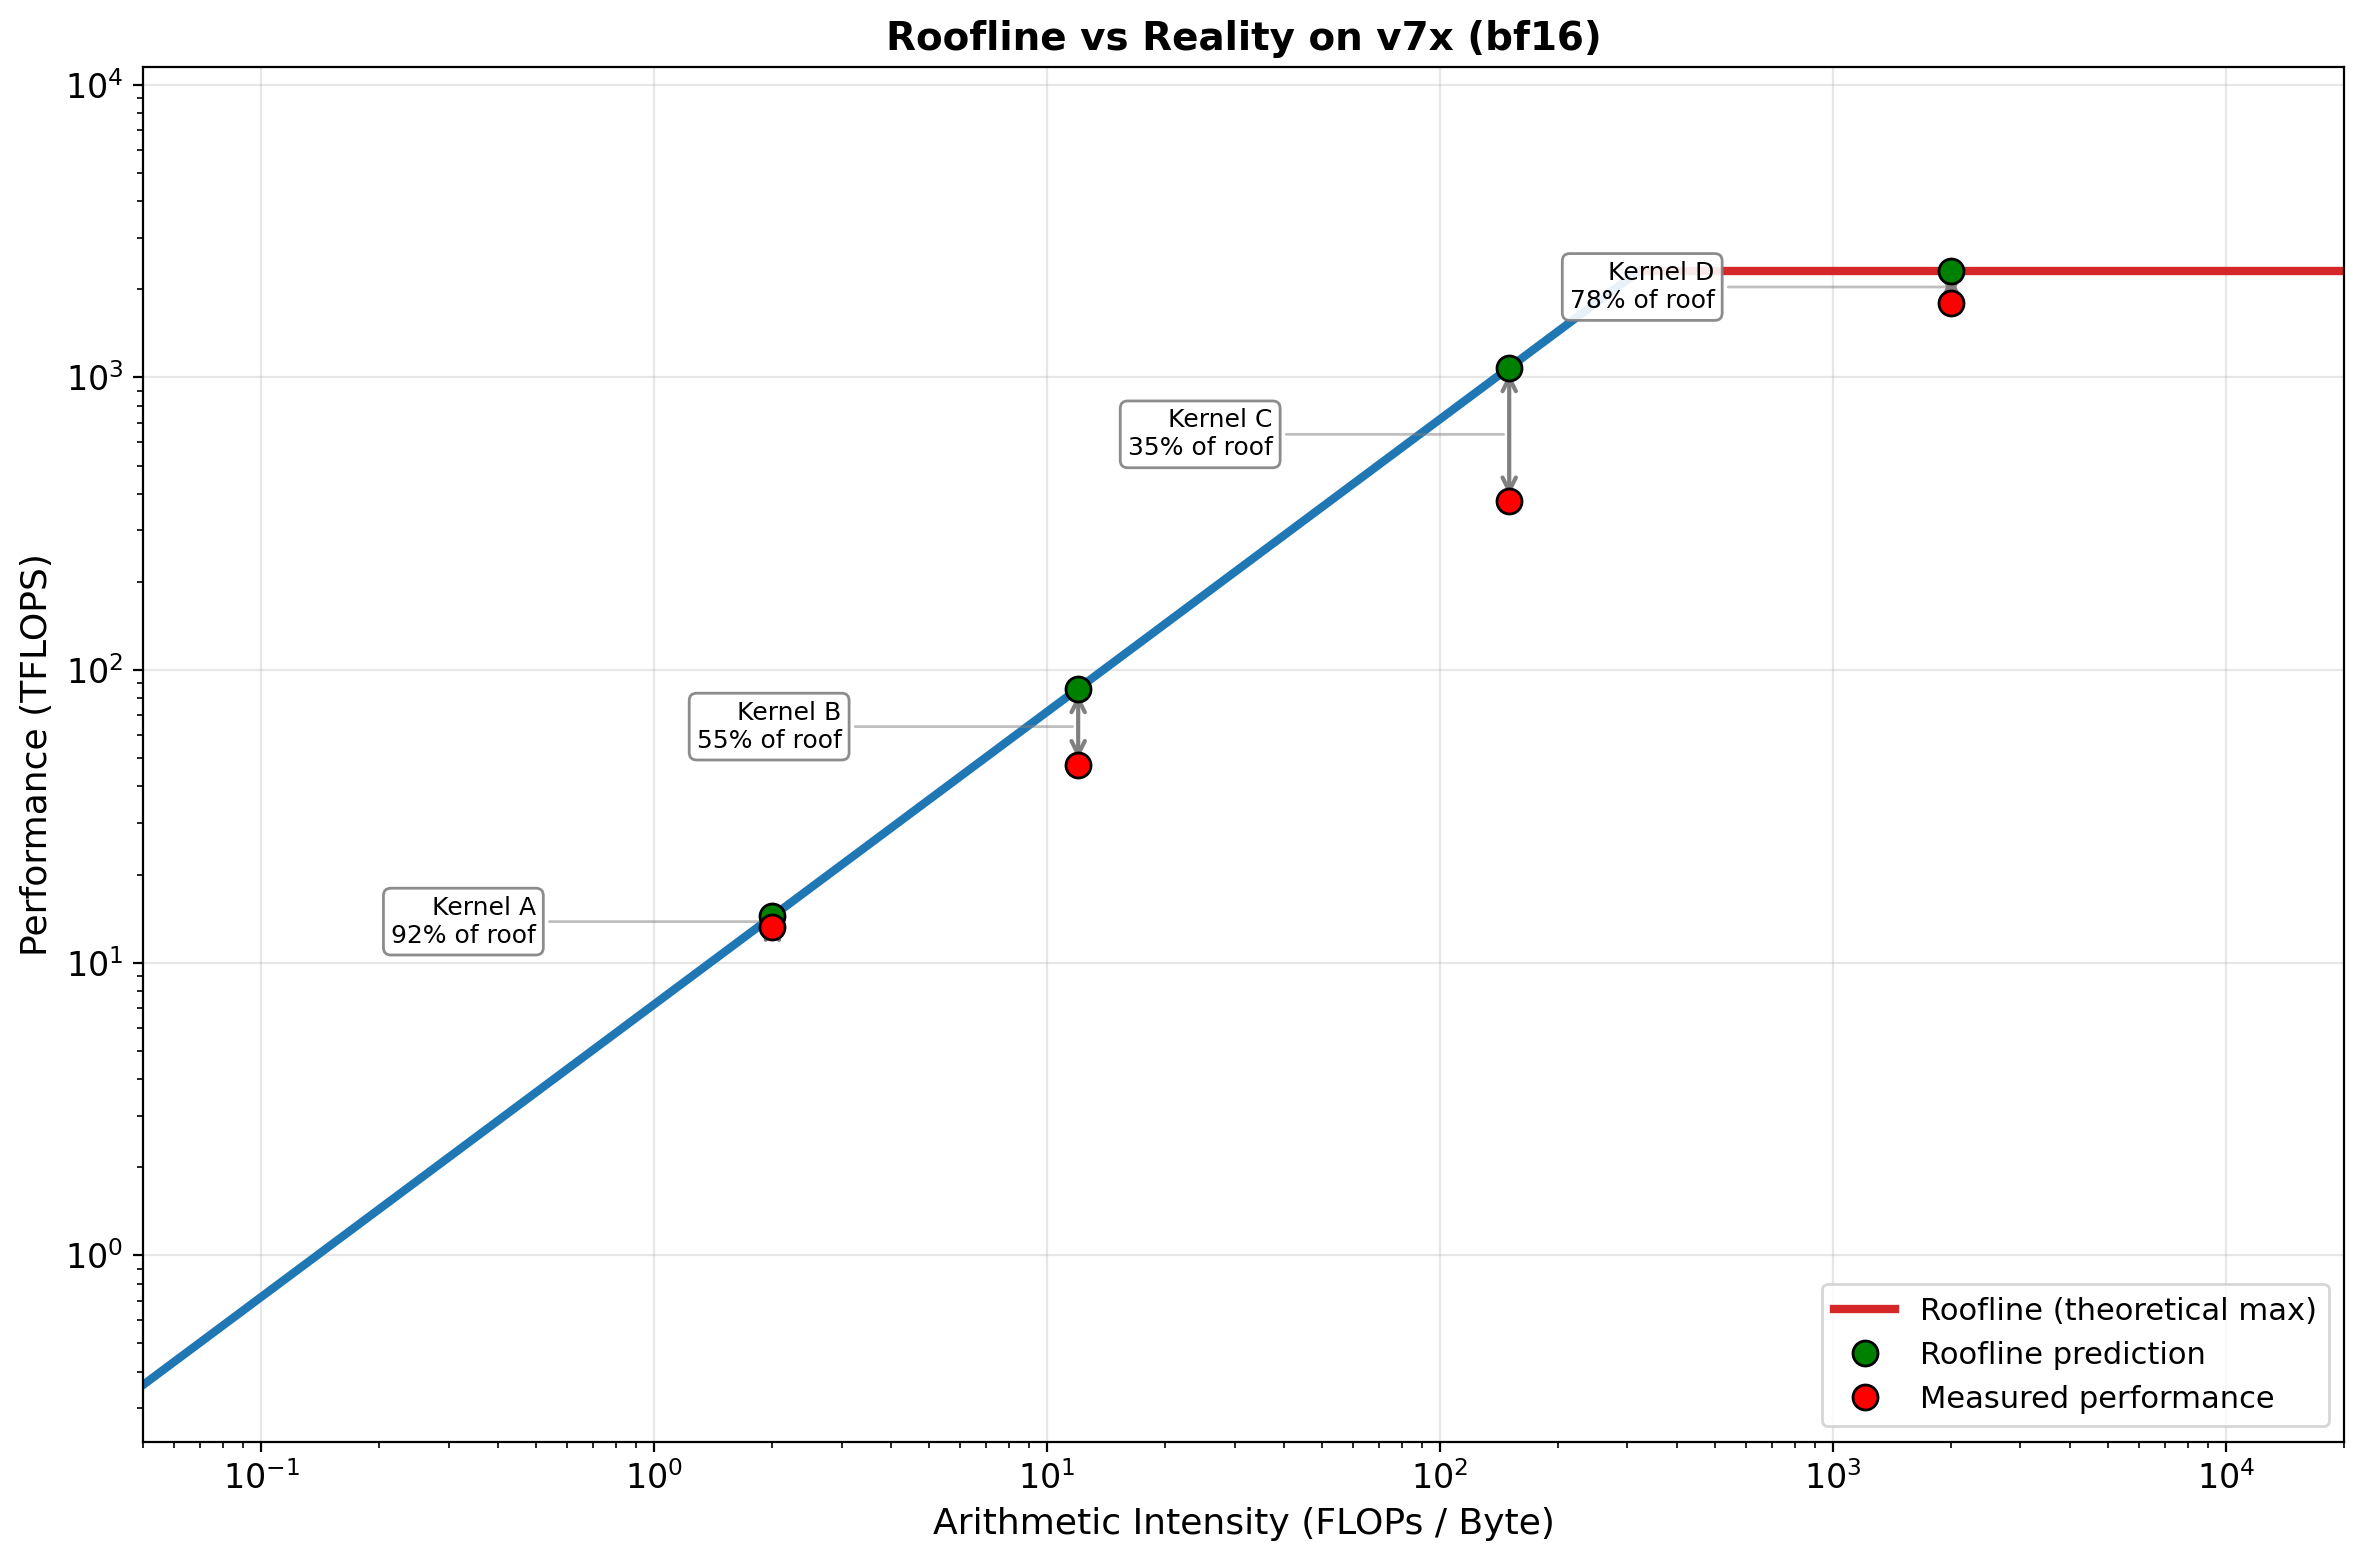

The gap (gray arrows) is your optimization opportunity.
Causes include: cache misses, pipeline stalls, poor tiling, launch overhead.
The roofline tells you WHICH ceiling to push against. Profiling tells you WHY you're not there.


In [ ]:
# @title Roofline vs Reality { display-mode: "form" }

# Show the gap between roofline prediction and "measured" performance
hw = HW_SPECS["v7x (bf16)"]
ai_vals = np.logspace(np.log10(0.05), np.log10(20000), 500)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot roofline with colored segments
ridge = hw['ridge']
roofline_vals = np.minimum(ai_vals * hw['peak_bw'], hw['peak_flops'])
mask_mem = ai_vals <= ridge
mask_comp = ai_vals >= ridge
ax.loglog(ai_vals[mask_mem], roofline_vals[mask_mem], '-', color='#1f77b4', linewidth=3)
ax.loglog(ai_vals[mask_comp], roofline_vals[mask_comp], '-', color='#d62728', linewidth=3,
          label='Roofline (theoretical max)')

# Placeholder kernels with a range of gaps
measured_kernels = [
    ("Kernel A",  2.0,   0.92),   # memory-bound, well-optimized
    ("Kernel B",  12,    0.55),   # memory-bound, moderate gap
    ("Kernel C",  150,   0.35),   # memory-bound, large gap
    ("Kernel D",  2000,  0.78),   # compute-bound, decent
]

for name, ai, efficiency in measured_kernels:
    ideal_perf = roofline_perf(ai, hw['peak_flops'], hw['peak_bw'])
    actual_perf = ideal_perf * efficiency

    # Plot ideal (on roofline) and actual (below)
    ax.plot(ai, ideal_perf, 'o', color='green', markersize=9, markeredgecolor='black', zorder=5)
    ax.plot(ai, actual_perf, 'o', color='red', markersize=9, markeredgecolor='black', zorder=5)
    ax.annotate('', xy=(ai, actual_perf), xytext=(ai, ideal_perf),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))

    # Label to the left of the point with a box
    label_x = ai * 0.25
    label_y = (ideal_perf * actual_perf)**0.5  # geometric mean for log scale
    ax.annotate(f'{name}\n{efficiency:.0%} of roof',
                xy=(ai, label_y), xytext=(label_x, label_y),
                fontsize=9, va='center', ha='right',
                arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.9))

# Legend entries
ax.plot([], [], 'o', color='green', markersize=9, markeredgecolor='black', label='Roofline prediction')
ax.plot([], [], 'o', color='red', markersize=9, markeredgecolor='black', label='Measured performance')

ax.set_xlabel('Arithmetic Intensity (FLOPs / Byte)', fontsize=13)
ax.set_ylabel('Performance (TFLOPS)', fontsize=13)
ax.set_title('Roofline vs Reality on v7x (bf16)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0.05, 20000)
ax.set_ylim(hw['peak_flops'] * 0.0001, hw['peak_flops'] * 5)
ax.grid(True, which="major", alpha=0.3)
plt.tight_layout()
plt.show()

print("The gap (gray arrows) is your optimization opportunity.")
print("Causes include: cache misses, pipeline stalls, poor tiling, launch overhead.")
print("The roofline tells you WHICH ceiling to push against. Profiling tells you WHY you're not there.")

## Misconception: "Memory bound = bad, compute bound = good"

Neither is inherently better. **What matters is how close you are to your ceiling.** A well-tuned memory-bound kernel is better than a poorly-tuned compute-bound one.

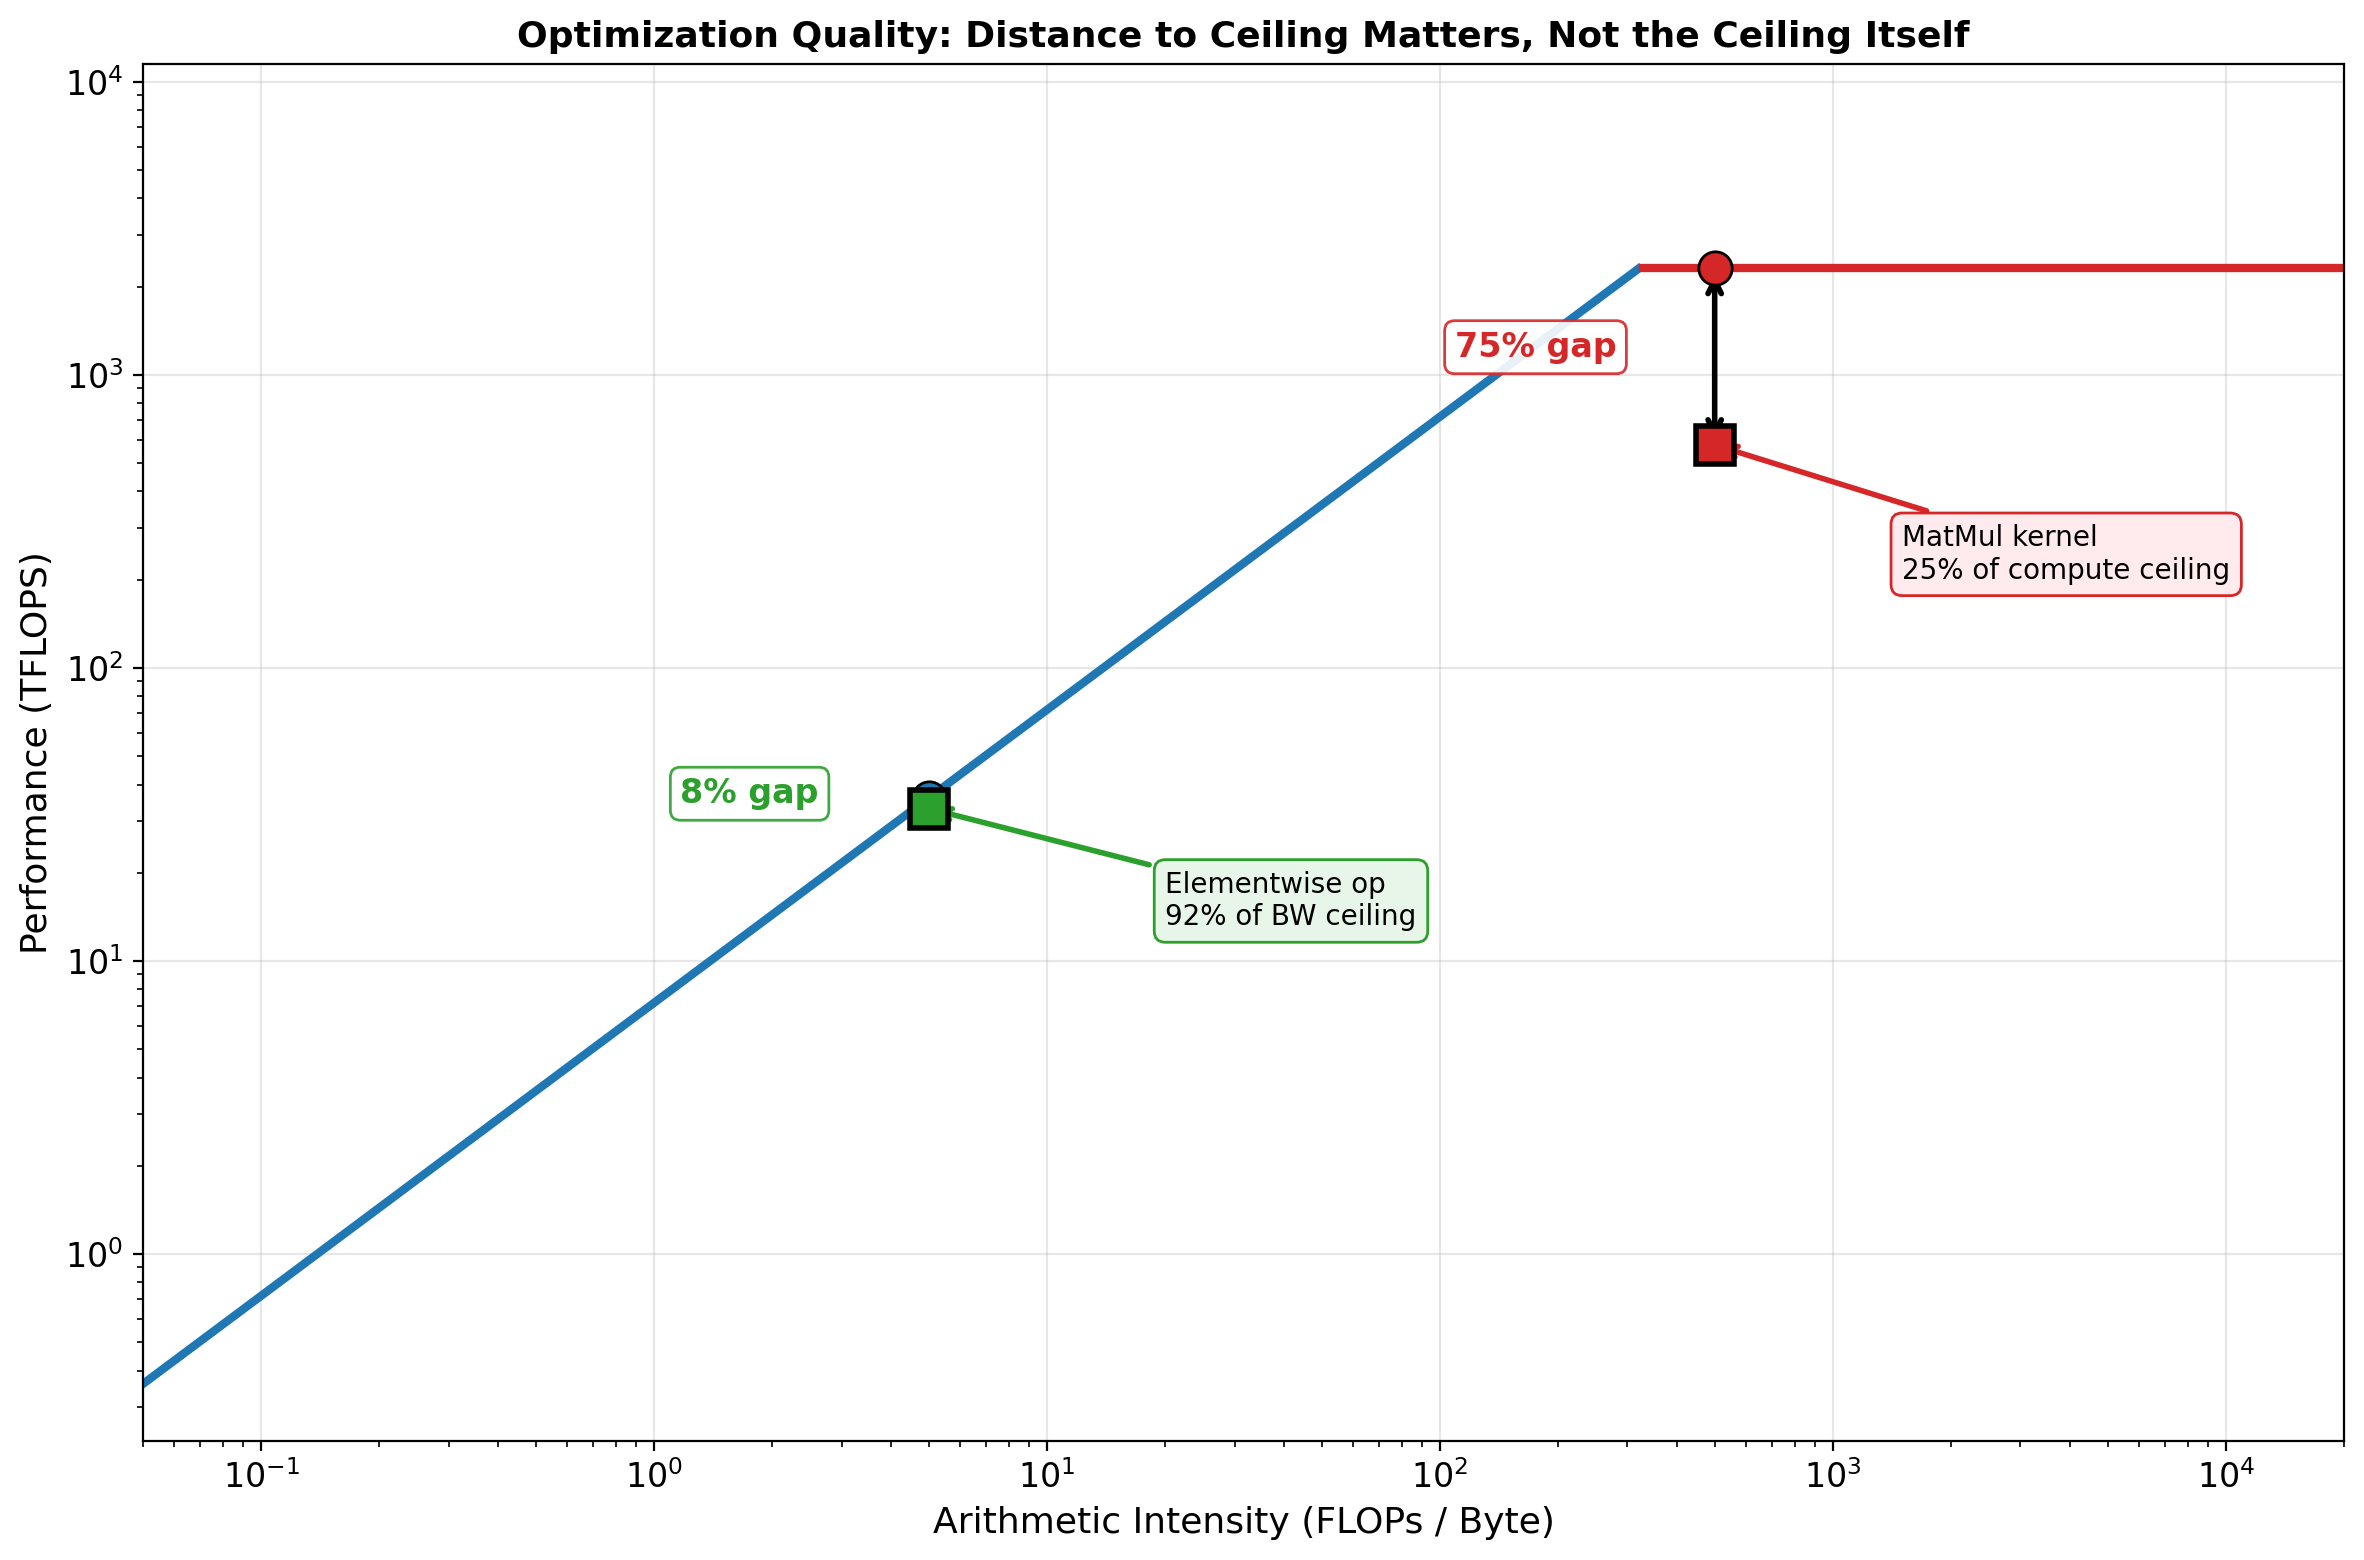

The memory-bound kernel (green) has far lower TFLOPS, but it's at 92% of its ceiling.
The compute-bound kernel (red) has higher TFLOPS, but is only at 25% of its ceiling.
The green kernel is better optimized. The red one has 75% headroom to improve.


In [ ]:
# @title Memory-Bound vs Compute-Bound Optimization { display-mode: "form" }

hw = HW_SPECS["v7x (bf16)"]
ridge = hw['ridge']
ai_vals = np.logspace(np.log10(0.05), np.log10(20000), 500)
roofline_vals = np.minimum(ai_vals * hw['peak_bw'], hw['peak_flops'])

fig, ax = plt.subplots(figsize=(12, 8))

# Colored roofline: blue (memory-bound slope) and red (compute ceiling)
mask_mem = ai_vals <= ridge
mask_comp = ai_vals >= ridge
ax.loglog(ai_vals[mask_mem], roofline_vals[mask_mem], '-', color='#1f77b4', linewidth=3)
ax.loglog(ai_vals[mask_comp], roofline_vals[mask_comp], '-', color='#d62728', linewidth=3)

# Kernel A: memory-bound, well-optimized (92% of BW ceiling)
ai_a = 5.0
roof_a = roofline_perf(ai_a, hw['peak_flops'], hw['peak_bw'])
actual_a = roof_a * 0.92
ax.plot(ai_a, roof_a, 'o', color='#1f77b4', markersize=12, markeredgecolor='black', zorder=5)
ax.plot(ai_a, actual_a, 's', color='#2ca02c', markersize=14, markeredgecolor='black', markeredgewidth=2, zorder=5)
ax.annotate(f'Elementwise op\n92% of BW ceiling',
            xy=(ai_a, actual_a), xytext=(ai_a * 4, actual_a * 0.4),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=2),
            bbox=dict(boxstyle='round,pad=0.4', fc='#e8f5e9', ec='#2ca02c'))

# Kernel B: compute-bound, poorly optimized (25% of compute ceiling)
ai_b = 500
roof_b = roofline_perf(ai_b, hw['peak_flops'], hw['peak_bw'])
actual_b = roof_b * 0.25
ax.plot(ai_b, roof_b, 'o', color='#d62728', markersize=12, markeredgecolor='black', zorder=5)
ax.plot(ai_b, actual_b, 's', color='#d62728', markersize=14, markeredgecolor='black', markeredgewidth=2, zorder=5)
ax.annotate(f'MatMul kernel\n25% of compute ceiling',
            xy=(ai_b, actual_b), xytext=(ai_b * 3, actual_b * 0.35),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=2),
            bbox=dict(boxstyle='round,pad=0.4', fc='#ffebee', ec='#d62728'))

# Gap arrows with large, clear labels
ax.annotate('', xy=(ai_a, actual_a), xytext=(ai_a, roof_a),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.annotate('', xy=(ai_b, actual_b), xytext=(ai_b, roof_b),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))

# Gap labels — clear, boxed, to the left of the arrows
ax.text(ai_a * 0.35, (roof_a * actual_a)**0.5, '8% gap',
        fontsize=12, fontweight='bold', ha='center', color='#2ca02c',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#2ca02c', alpha=0.9))
ax.text(ai_b * 0.35, (roof_b * actual_b)**0.5, '75% gap',
        fontsize=12, fontweight='bold', ha='center', color='#d62728',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#d62728', alpha=0.9))

ax.set_xlabel('Arithmetic Intensity (FLOPs / Byte)', fontsize=13)
ax.set_ylabel('Performance (TFLOPS)', fontsize=13)
ax.set_title('Optimization Quality: Distance to Ceiling Matters, Not the Ceiling Itself', fontsize=13, fontweight='bold')
ax.set_xlim(0.05, 20000)
ax.set_ylim(hw['peak_flops'] * 0.0001, hw['peak_flops'] * 5)
ax.grid(True, which="major", alpha=0.3)
plt.tight_layout()
plt.show()

print("The memory-bound kernel (green) has far lower TFLOPS, but it's at 92% of its ceiling.")
print("The compute-bound kernel (red) has higher TFLOPS, but is only at 25% of its ceiling.")
print("The green kernel is better optimized. The red one has 75% headroom to improve.")

---

# 7. What Rooflines Can't Tell You

The roofline model is powerful *because* it's simple — two ceilings, one number (AI). But that simplicity has real blind spots.

## Cache and Memory Hierarchy

The standard roofline uses **peak HBM bandwidth** as the single memory ceiling. But real hardware has multiple memory levels (registers, SRAM/CMEM, HBM), each with vastly different bandwidths. A kernel with good data reuse in SRAM can exceed the HBM roofline prediction — and a poorly-tiled kernel can fall below it.

The good news: you can extend the roofline model to account for this. A **hierarchical roofline** adds a second (steeper) memory ceiling for the faster cache level.

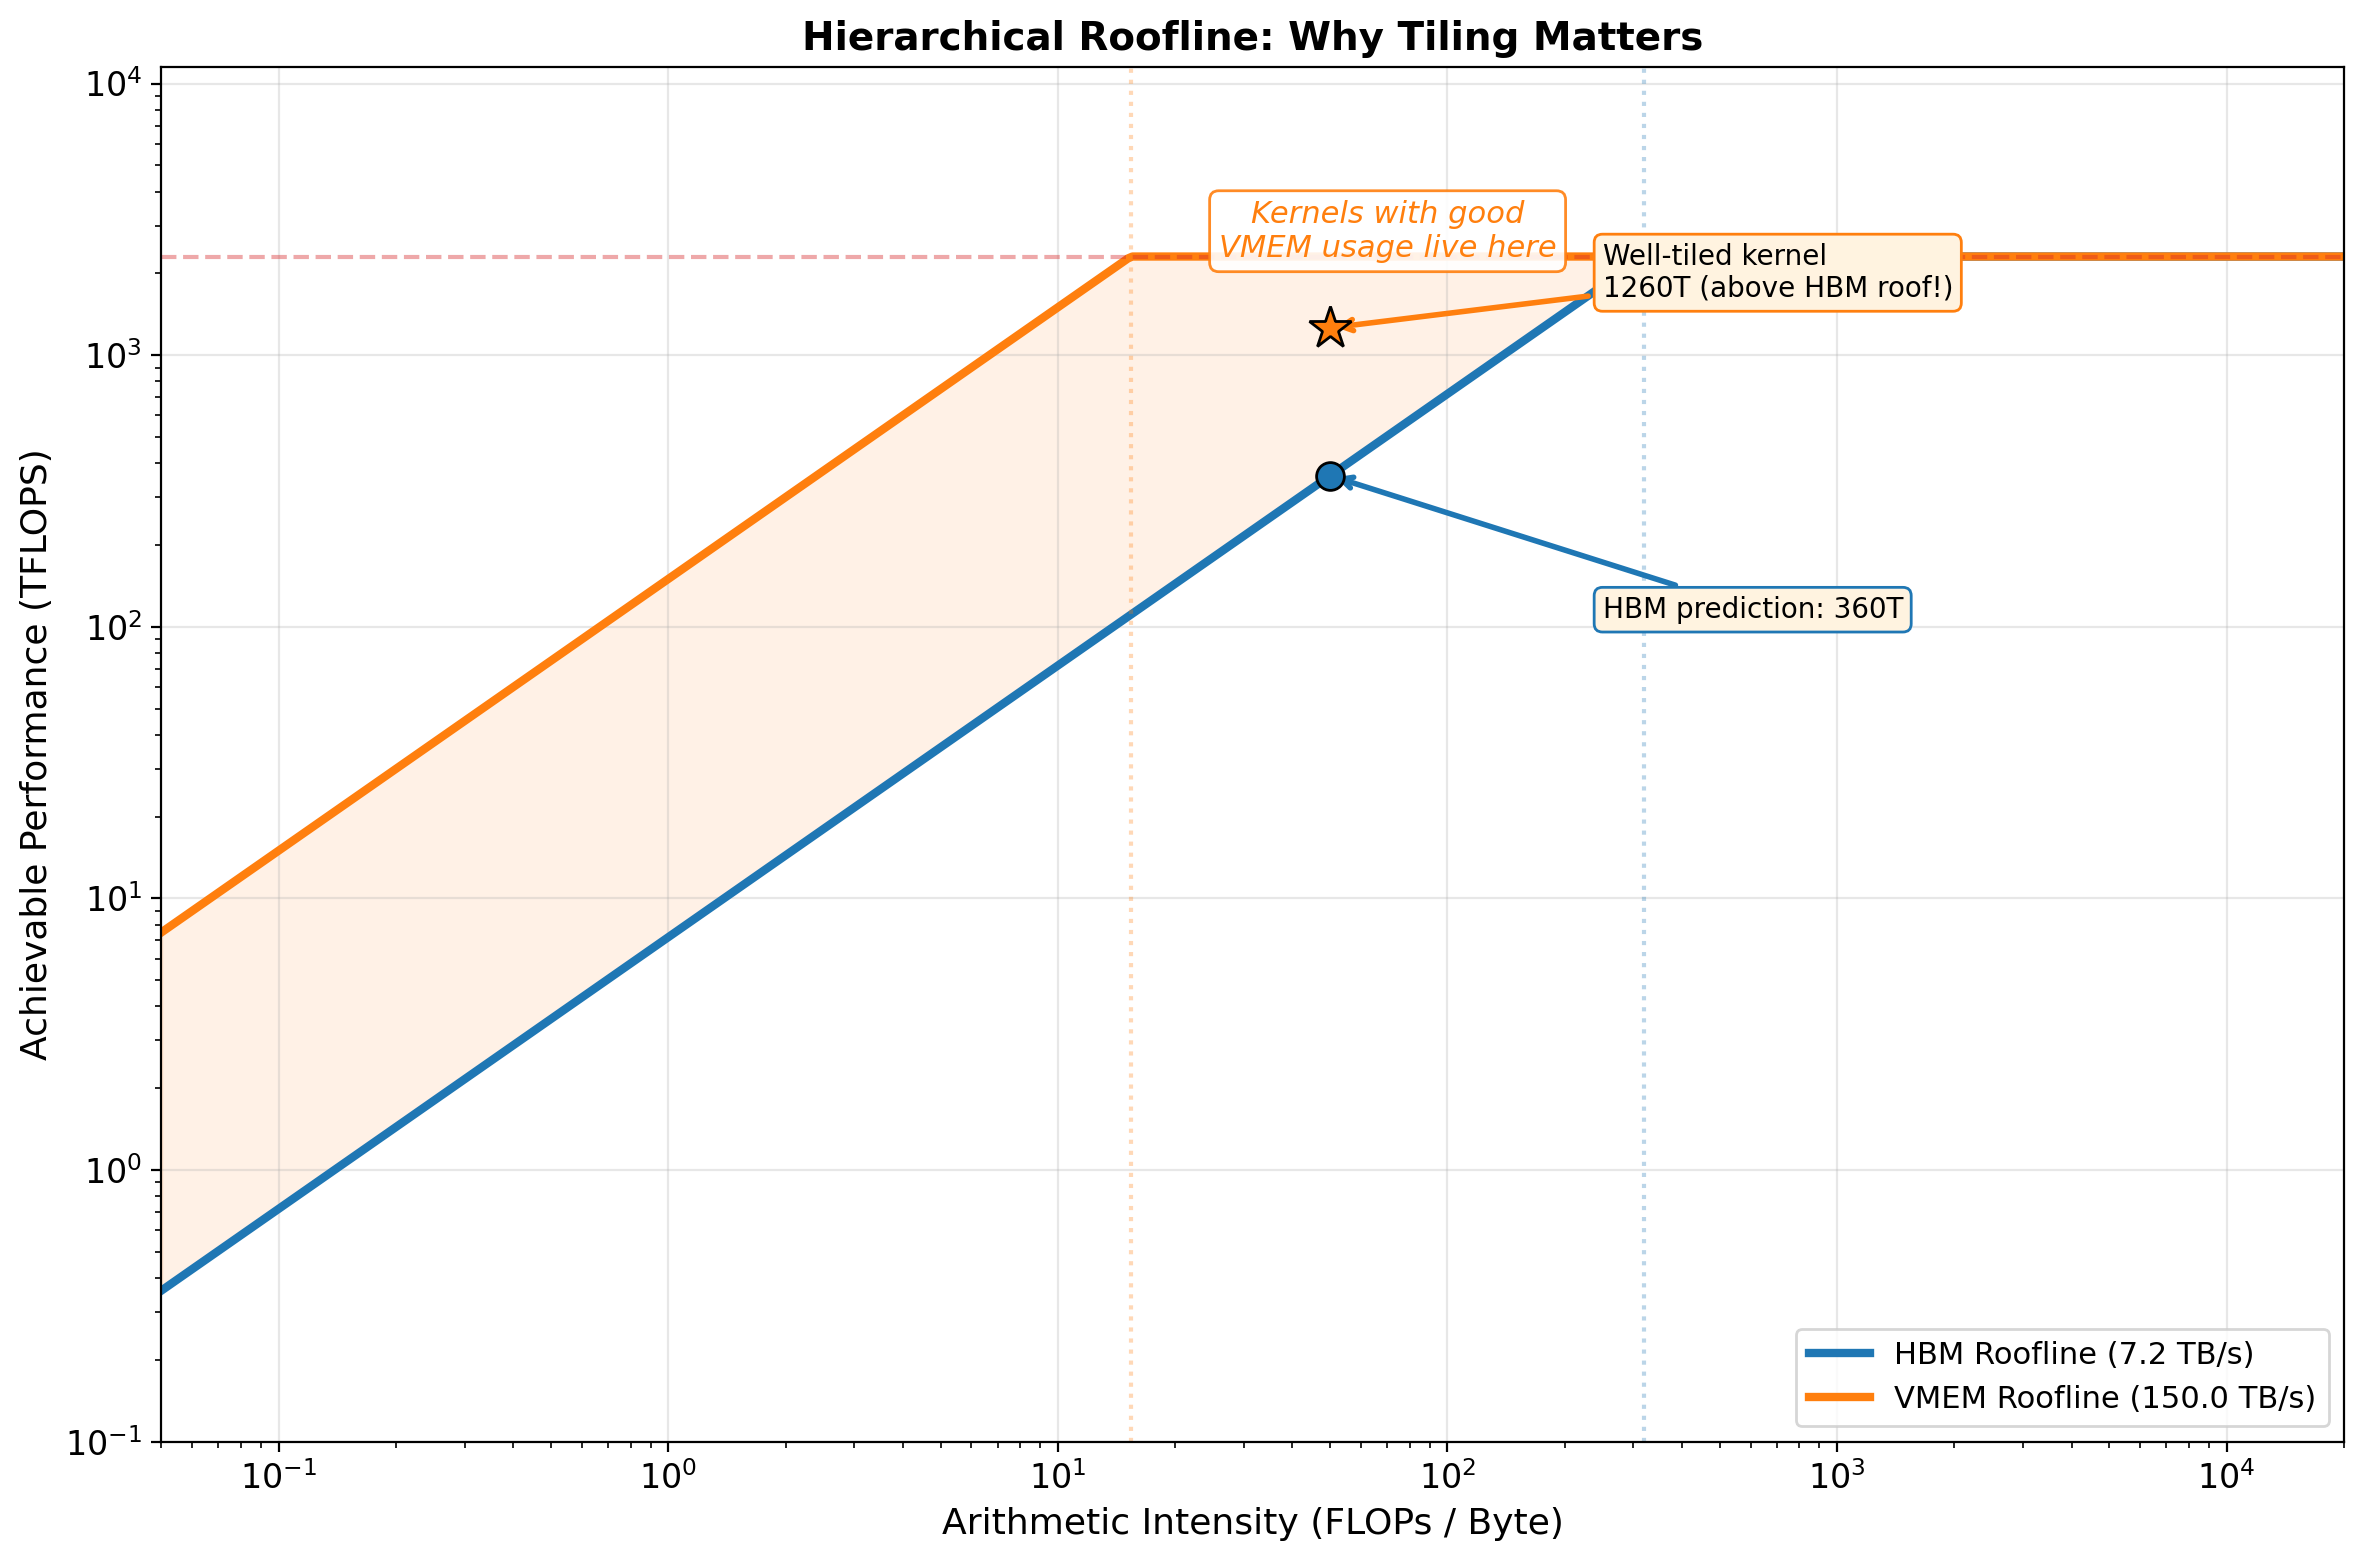

Strategy: If your kernel is between the HBM and VMEM rooflines, tiling is your lever.
  - Tile dimensions to fit working sets in VMEM
  - Reorder loops so data is reused before being evicted
  - On TPU: Pallas kernels give you explicit VMEM control
  - Profile with memory tracing to verify your tiles actually hit VMEM


In [ ]:
# @title Hierarchical Roofline: HBM vs VMEM { display-mode: "form" }

# Real values are architecture-dependent; these are representative
hbm_bw = 7.2    # TB/s (v7x HBM)
vmem_bw = 150.0  # TB/s (illustrative on-chip bandwidth)
peak_flops = 2307  # TFLOPS (v7x bf16)

ridge_hbm = peak_flops / hbm_bw    # ~320
ridge_vmem = peak_flops / vmem_bw   # ~15

ai_vals = np.logspace(np.log10(0.05), np.log10(20000), 500)

fig, ax = plt.subplots(figsize=(12, 8))

# HBM roofline (standard)
hbm_roof = np.minimum(ai_vals * hbm_bw, peak_flops)
ax.loglog(ai_vals, hbm_roof, '-', color='#1f77b4', linewidth=3, label=f'HBM Roofline ({hbm_bw} TB/s)')

# vmem roofline (extended)
vmem_roof = np.minimum(ai_vals * vmem_bw, peak_flops)
ax.loglog(ai_vals, vmem_roof, '-', color='#ff7f0e', linewidth=3, label=f'VMEM Roofline ({vmem_bw} TB/s)')

# Compute ceiling
ax.axhline(y=peak_flops, color='#d62728', linestyle='--', alpha=0.4, linewidth=1.5)

# Shade the "bonus zone" — between HBM and vmem rooflines
ax.fill_between(ai_vals, hbm_roof, vmem_roof, where=(vmem_roof > hbm_roof),
                color='#ff7f0e', alpha=0.1)
# Label the bonus zone
bonus_x = 10**((np.log10(ridge_vmem) + np.log10(ridge_hbm)) / 2)
bonus_y = 10**((np.log10(bonus_x * hbm_bw) + np.log10(bonus_x * vmem_bw)) / 2)
ax.text(bonus_x, bonus_y, 'Kernels with good\nVMEM usage live here',
        fontsize=11, ha='center', style='italic', color='#ff7f0e',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#ff7f0e', alpha=0.9))

# Example: well-tiled matmul exceeds HBM prediction
example_ai = 50
hbm_pred = roofline_perf(example_ai, peak_flops, hbm_bw)
sram_pred = roofline_perf(example_ai, peak_flops, vmem_bw)
actual = hbm_pred * 3.5  # achieves well above HBM roofline due to VMEM

ax.plot(example_ai, hbm_pred, 'o', color='#1f77b4', markersize=10, markeredgecolor='black', zorder=5)
ax.plot(example_ai, actual, '*', color='#ff7f0e', markersize=16, markeredgecolor='black', zorder=5)
ax.annotate(f'Well-tiled kernel\n{actual:.0f}T (above HBM roof!)',
            xy=(example_ai, actual), xytext=(example_ai * 5, actual * 1.3),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='#ff7f0e', lw=2),
            bbox=dict(boxstyle='round,pad=0.3', fc='#fff3e0', ec='#ff7f0e'))
ax.annotate(f'HBM prediction: {hbm_pred:.0f}T',
            xy=(example_ai, hbm_pred), xytext=(example_ai * 5, hbm_pred * 0.3),
            fontsize=10, ha='left',
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=2),
            bbox=dict(boxstyle='round,pad=0.3', fc='#fff3e0', ec='#1f77b4'))

# Ridge point annotations
ax.axvline(x=ridge_hbm, color='#1f77b4', linestyle=':', alpha=0.3)
ax.axvline(x=ridge_vmem, color='#ff7f0e', linestyle=':', alpha=0.3)

ax.set_xlabel('Arithmetic Intensity (FLOPs / Byte)', fontsize=13)
ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=13)
ax.set_title('Hierarchical Roofline: Why Tiling Matters', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0.05, 20000)
ax.set_ylim(0.1, peak_flops * 5)
ax.grid(True, which="major", alpha=0.3)
plt.tight_layout()
plt.show()

print("Strategy: If your kernel is between the HBM and VMEM rooflines, tiling is your lever.")
print("  - Tile dimensions to fit working sets in VMEM")
print("  - Reorder loops so data is reused before being evicted")
print("  - On TPU: Pallas kernels give you explicit VMEM control")
print("  - Profile with memory tracing to verify your tiles actually hit VMEM")

## Multi-Chip and Interconnect Costs

For distributed workloads, the roofline says nothing about inter-chip communication. The time spent on AllReduce, AllGather, and other collectives is invisible to the per-chip roofline. In practice, interconnect bandwidth creates an additional overhead that reduces the effective compute time available.

We can model this: if a fraction of your step time is spent on communication, your **effective roofline** is lower by that fraction.

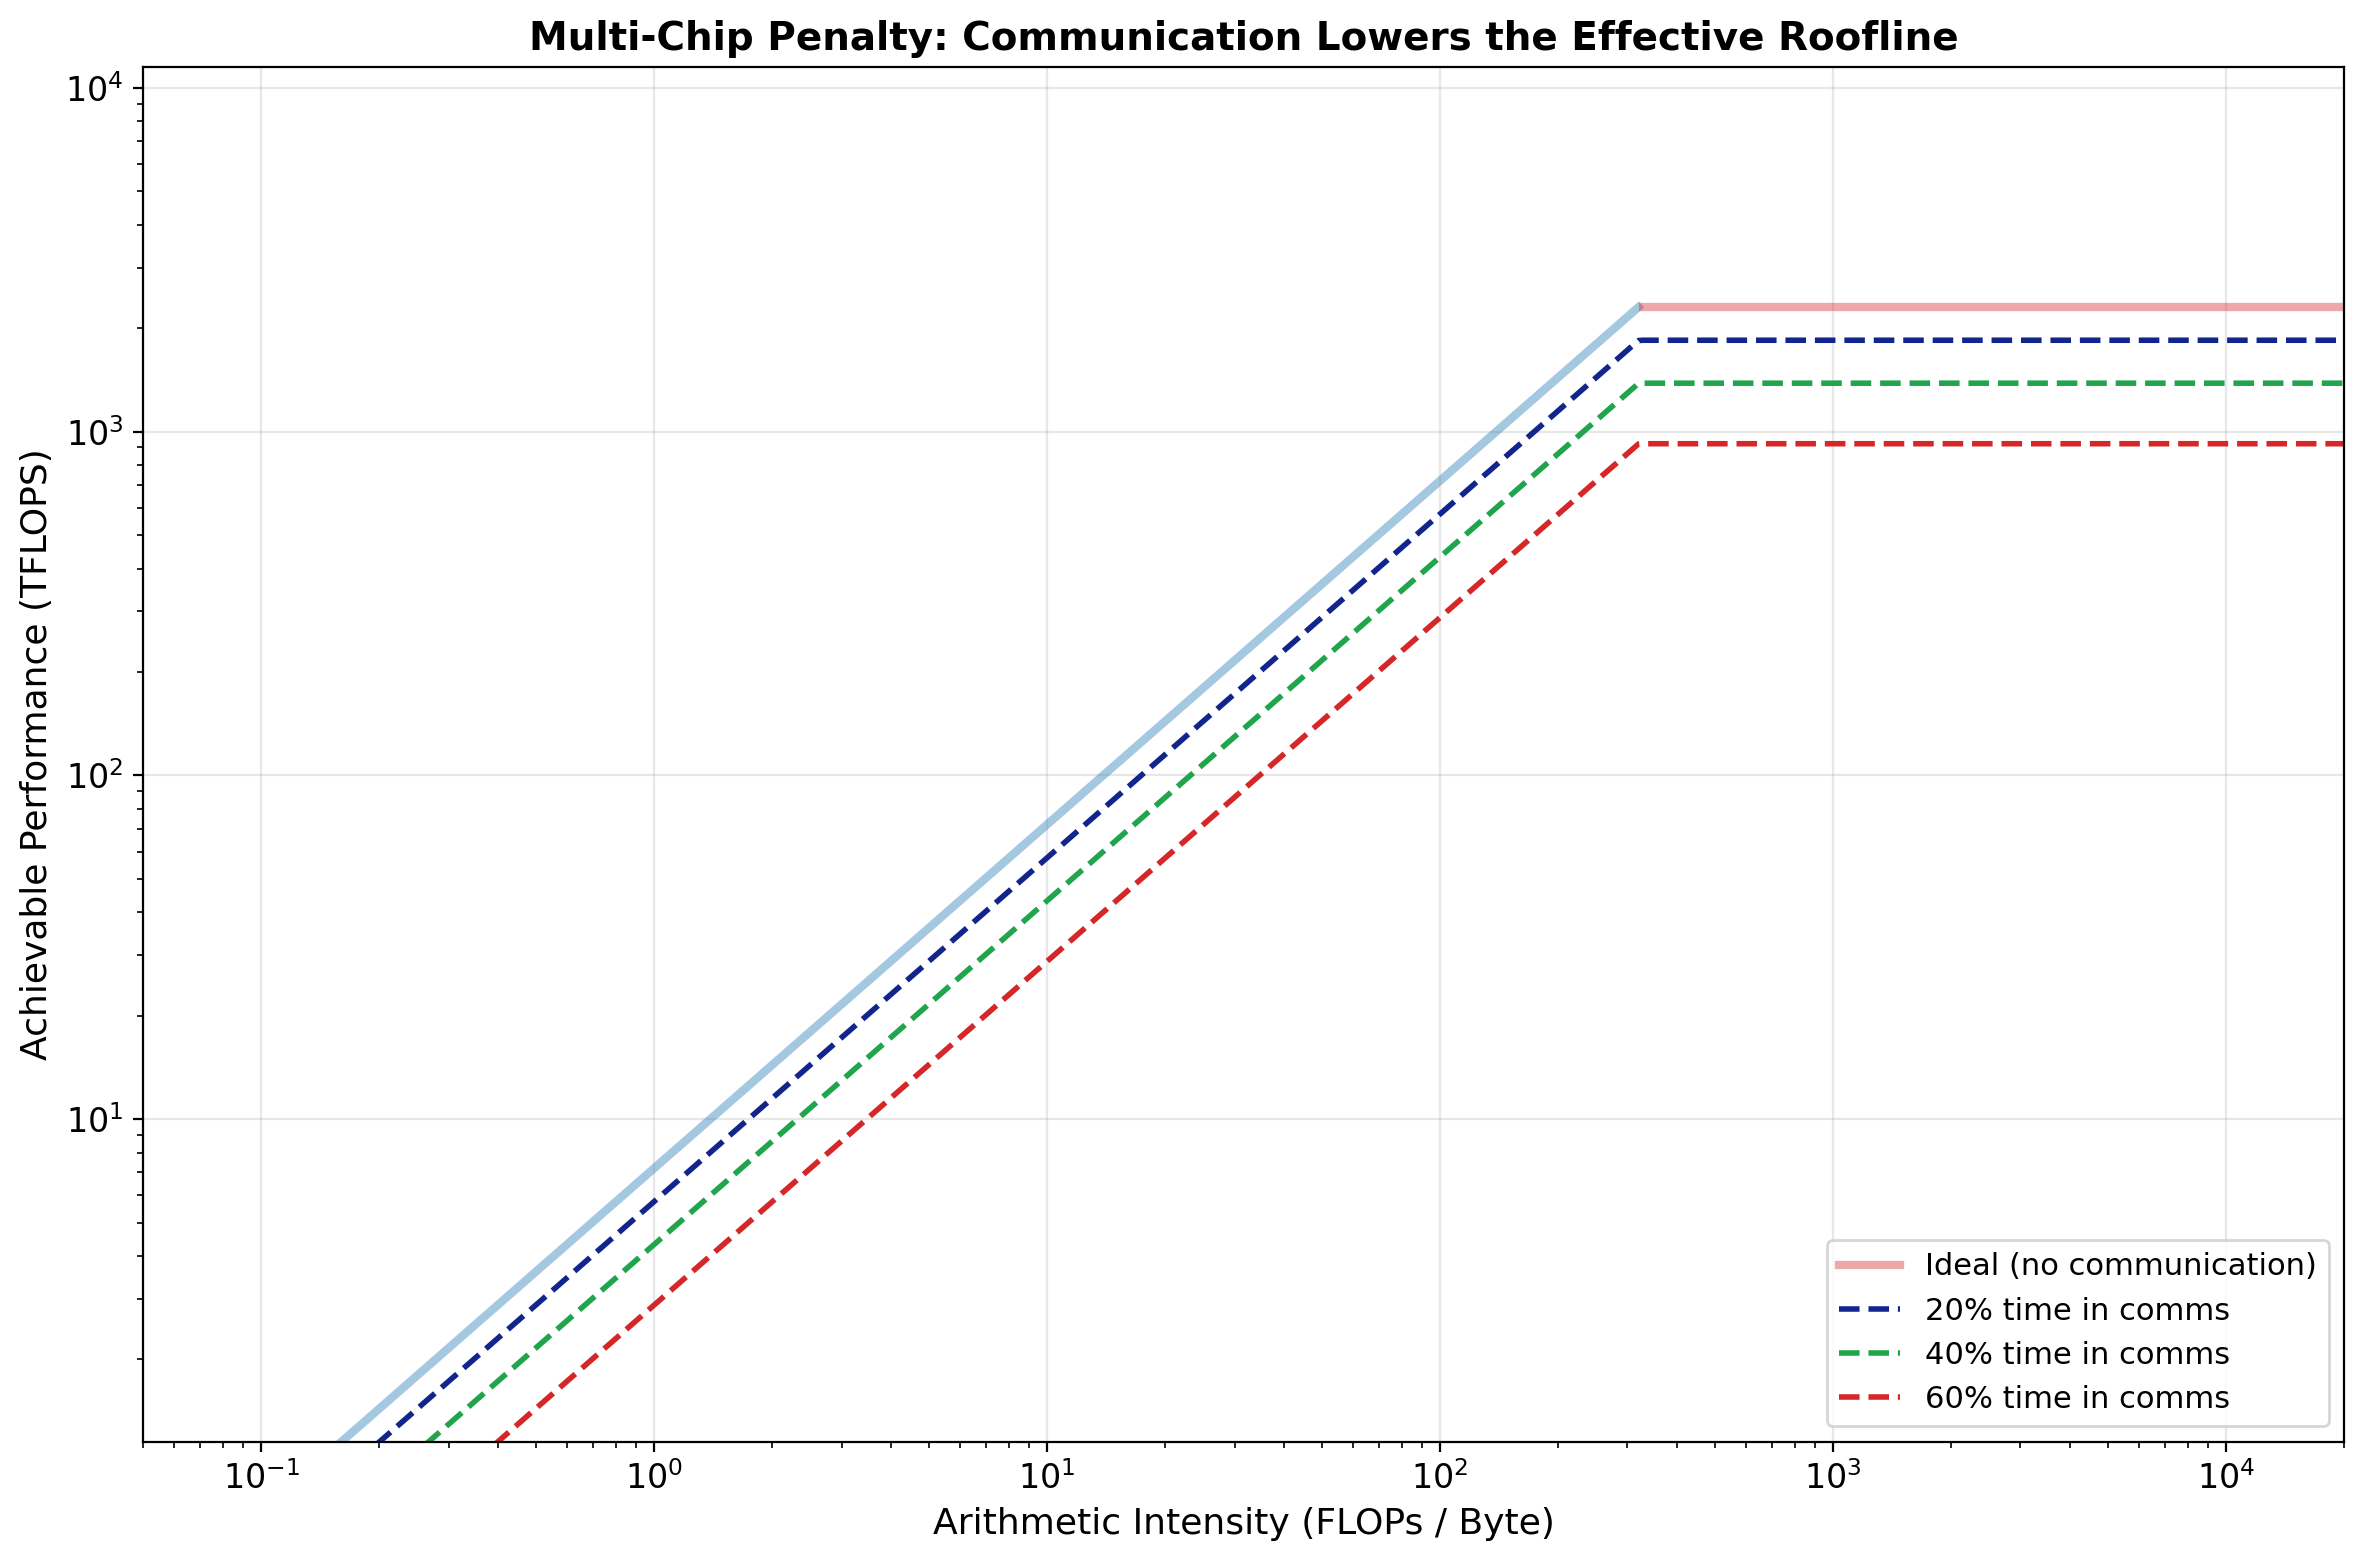

Strategy: Minimize the communication fraction of your step time.
  - Overlap compute with communication (async collectives)
  - Choose parallelism strategies that minimize bytes transferred
  - TP within a node (fast ICI), FSDP/PP across nodes (slower DCN)
  - Profile: what fraction of your step is compute vs comms vs idle?


In [ ]:
# @title Communication Overhead: Effective Roofline { display-mode: "form" }

hw = HW_SPECS['v7x (bf16)']
ai_vals = np.logspace(np.log10(0.05), np.log10(20000), 500)
ridge = hw['ridge']

fig, ax = plt.subplots(figsize=(12, 8))

# Ideal single-chip roofline
ideal_roof = np.minimum(ai_vals * hw['peak_bw'], hw['peak_flops'])
mask_mem = ai_vals <= ridge
mask_comp = ai_vals >= ridge
ax.loglog(ai_vals[mask_mem], ideal_roof[mask_mem], '-', color='#1f77b4', linewidth=3, alpha=0.4)
ax.loglog(ai_vals[mask_comp], ideal_roof[mask_comp], '-', color='#d62728', linewidth=3, alpha=0.4,
          label='Ideal (no communication)')

# Effective rooflines at different communication fractions
comm_fractions = [0.20, 0.40, 0.60]
comm_colors = ["#12258d", "#20a44c", '#d62728']
for frac, color in zip(comm_fractions, comm_colors):
    effective = ideal_roof * (1 - frac)
    ax.loglog(ai_vals, effective, '--', color=color, linewidth=2,
              label=f'{frac:.0%} time in comms')


ax.set_xlabel('Arithmetic Intensity (FLOPs / Byte)', fontsize=13)
ax.set_ylabel('Achievable Performance (TFLOPS)', fontsize=13)
ax.set_title('Multi-Chip Penalty: Communication Lowers the Effective Roofline', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0.05, 20000)
ax.set_ylim(hw['peak_flops'] * 0.0005, hw['peak_flops'] * 5)
ax.grid(True, which='major', alpha=0.3)
plt.tight_layout()
plt.show()

print('Strategy: Minimize the communication fraction of your step time.')
print('  - Overlap compute with communication (async collectives)')
print('  - Choose parallelism strategies that minimize bytes transferred')
print('  - TP within a node (fast ICI), FSDP/PP across nodes (slower DCN)')
print('  - Profile: what fraction of your step is compute vs comms vs idle?')

## Kernel Fusion: A Limitation You Can Exploit

Rooflines are good for analyzing **one kernel at a time**. But as we saw in Section 4, fusing multiple memory-bound operations into a single kernel eliminates intermediate HBM round-trips, shifting you right on the x-axis without changing the math.

This is also a blind spot: the roofline for *unfused* ops can be misleadingly pessimistic. If XLA or Pallas fuses your elementwise chain, the *effective* AI is much higher than the per-op calculation suggests. Always check what the compiler actually emits before concluding you're memory-bound.

## Latency and Pipeline Bubbles

The roofline assumes steady-state throughput. In reality, kernels have startup costs, synchronization barriers, and pipeline drain time. For small, short-running kernels, these overheads can dominate. This is why a kernel that looks great on the roofline (high AI, close to ceiling) can still be slow if it's launched thousands of times per step with tiny inputs.

**Strategy**: Batch small operations together, use persistent kernels, and minimize host-device synchronization points.

---

# 8. Summary — What To Do Next

## Key Insights

Comparing v7x, v6e, and v5p across two precision modes:

1. **Ridge points are moving right**: Compute grows faster than bandwidth. More of your kernels are memory-bound on newer hardware.
2. **Same kernel, different story**: An operation that's compute-bound on v5p can become memory-bound on v7x. Your optimization strategy must evolve with the hardware.
3. **Fusion is the biggest lever for memory-bound ops**: Fusing elementwise chains eliminates HBM round-trips, shifting AI right without changing the math. A 4-op chain fused into one kernel gets 4x the AI and 4x the roofline throughput.

## What To Do Based on Your Bottleneck

| If you're... | Try... |
|-------------|--------|
| **Memory bound, far from roofline** | Better tiling, data layout optimization, reduce unnecessary reads |
| **Memory bound, close to roofline** | Kernel fusion (combine elementwise ops), reduce precision, increase batch size |
| **Compute bound, far from roofline** | Check MXU/ALU utilization, vectorization, reduce pipeline stalls |
| **Compute bound, close to roofline** | You're well-optimized! Look for algorithmic improvements or scale up |
| **Way below both ceilings** | Profile for launch overhead, synchronization, cache thrashing — roofline can't diagnose these |

## How To Use This In Practice

1. **Calculate AI** for your kernel (or measure with `cost_analysis`)
2. **Plot it** on the roofline for your target hardware
3. **Measure actual performance** with profiling
4. **Compare** actual vs roofline — the gap tells you how much room you have
5. **Diagnose** using the bottleneck type to guide your optimization strategy